In [11]:
import scanpy as sc
import os

base_path = "/Users/prashammarfatia/Downloads"
gsm_ids = [f"GSM64354{str(i).zfill(2)}" for i in range(3, 23)]
output_dir = os.path.join(base_path, "processed_h5ad")
os.makedirs(output_dir, exist_ok=True)

for gsm_id in gsm_ids:
    gsm_dir = os.path.join(base_path, gsm_id)
    try:
        print(f" Processing {gsm_id}...")
        adata = sc.read_10x_mtx(
            gsm_dir,
            var_names="gene_symbols"
        )
        adata.obs["sample"] = gsm_id
        adata.write_h5ad(os.path.join(output_dir, f"{gsm_id}.h5ad"), compression="gzip")
    except Exception as e:
        print(f" Skipped {gsm_id}: {e}")


 Processing GSM6435403...
 Processing GSM6435404...
 Processing GSM6435405...
 Processing GSM6435406...
 Processing GSM6435407...
 Processing GSM6435408...
 Processing GSM6435409...
 Processing GSM6435410...
 Processing GSM6435411...
 Processing GSM6435412...
 Processing GSM6435413...
 Processing GSM6435414...
 Processing GSM6435415...
 Processing GSM6435416...
 Processing GSM6435417...
 Processing GSM6435418...
 Processing GSM6435419...
 Processing GSM6435420...
 Processing GSM6435421...
 Processing GSM6435422...


In [12]:
import scanpy as sc
import pandas as pd
import anndata as ad
import os
import gc

# Configure for memory efficiency
sc.settings.verbosity = 3
sc.settings.n_jobs = 1
gc.set_threshold(700, 10, 10)

# Paths
base_path = "/Users/prashammarfatia/Downloads"
processed_dir = os.path.join(base_path, "processed_h5ad")

# Check what files we have
h5ad_files = sorted([f for f in os.listdir(processed_dir) if f.endswith('.h5ad')])
print(f"Found {len(h5ad_files)} files:")
for f in h5ad_files:
    print(f"  {f}")

Found 20 files:
  GSM6435403.h5ad
  GSM6435404.h5ad
  GSM6435405.h5ad
  GSM6435406.h5ad
  GSM6435407.h5ad
  GSM6435408.h5ad
  GSM6435409.h5ad
  GSM6435410.h5ad
  GSM6435411.h5ad
  GSM6435412.h5ad
  GSM6435413.h5ad
  GSM6435414.h5ad
  GSM6435415.h5ad
  GSM6435416.h5ad
  GSM6435417.h5ad
  GSM6435418.h5ad
  GSM6435419.h5ad
  GSM6435420.h5ad
  GSM6435421.h5ad
  GSM6435422.h5ad


In [13]:
def concatenate_basic_files(batch_size=4):
    """Concatenate the basic h5ad files without guide info"""
    adata_combined = None
    
    for i in range(0, len(h5ad_files), batch_size):
        batch_files = h5ad_files[i:i+batch_size]
        batch_list = []
        
        print(f"\n Batch {i//batch_size + 1}/{(len(h5ad_files)-1)//batch_size + 1}")
        
        for h5ad_file in batch_files:
            try:
                print(f"  Loading {h5ad_file}...")
                adata = sc.read_h5ad(os.path.join(processed_dir, h5ad_file))
                print(f"    Shape: {adata.shape}")
                
                batch_list.append(adata)
                
            except Exception as e:
                print(f"   Error loading {h5ad_file}: {e}")
                continue
        
        # Concatenate current batch
        if batch_list:
            print("   Concatenating batch...")
            
            # Get sample keys from the sample column that already exists
            sample_keys = [adata.obs["sample"].iloc[0] for adata in batch_list]
            
            batch_combined = ad.concat(
                batch_list, 
                label="batch_sample", 
                keys=sample_keys,
                index_unique="-",
                join='outer'
            )
            
            if adata_combined is None:
                adata_combined = batch_combined
            else:
                print("   Merging with previous batches...")
                adata_combined = ad.concat(
                    [adata_combined, batch_combined], 
                    index_unique="-",
                    join='outer'
                )
            
            print(f"   Cumulative shape: {adata_combined.shape}")
        
        # Clean up
        del batch_list
        if 'batch_combined' in locals():
            del batch_combined
        gc.collect()
    
    return adata_combined

# Run concatenation
print(" Starting concatenation of basic files...")
adata_all = concatenate_basic_files(batch_size=4)

 Starting concatenation of basic files...

 Batch 1/5
  Loading GSM6435403.h5ad...
    Shape: (32991, 36601)
  Loading GSM6435404.h5ad...
    Shape: (16699, 36601)
  Loading GSM6435405.h5ad...
    Shape: (28180, 36601)
  Loading GSM6435406.h5ad...
    Shape: (30847, 36601)
   Concatenating batch...
   Cumulative shape: (108717, 36601)

 Batch 2/5
  Loading GSM6435407.h5ad...
    Shape: (23875, 36601)
  Loading GSM6435408.h5ad...
    Shape: (23383, 36601)
  Loading GSM6435409.h5ad...
    Shape: (45060, 36601)
  Loading GSM6435410.h5ad...
    Shape: (39110, 36601)
   Concatenating batch...
   Merging with previous batches...
   Cumulative shape: (240145, 36601)

 Batch 3/5
  Loading GSM6435411.h5ad...
    Shape: (44166, 36601)
  Loading GSM6435412.h5ad...
    Shape: (50481, 36601)
  Loading GSM6435413.h5ad...
    Shape: (47756, 36601)
  Loading GSM6435414.h5ad...
    Shape: (79883, 36601)
   Concatenating batch...
   Merging with previous batches...
   Cumulative shape: (462431, 36601)



In [14]:
print(f" Combined dataset shape: {adata_all.shape}")
print(f"Samples: {adata_all.obs['sample'].nunique()}")
print(f"Sample distribution:")
print(adata_all.obs['sample'].value_counts().sort_index())

 Combined dataset shape: (822156, 36601)
Samples: 20
Sample distribution:
sample
GSM6435403    32991
GSM6435404    16699
GSM6435405    28180
GSM6435406    30847
GSM6435407    23875
GSM6435408    23383
GSM6435409    45060
GSM6435410    39110
GSM6435411    44166
GSM6435412    50481
GSM6435413    47756
GSM6435414    79883
GSM6435415    41052
GSM6435416    42140
GSM6435417    42086
GSM6435418    46718
GSM6435419    49407
GSM6435420    46025
GSM6435421    46915
GSM6435422    45382
Name: count, dtype: int64


In [15]:
def add_guide_info_to_combined(adata_combined):
    """Add guide information to the already combined dataset"""
    
    print(" Adding guide information...")
    
    # Initialize guide columns
    adata_combined.obs["Guide"] = "NA"
    adata_combined.obs["Gene"] = "NA"
    
    # Get unique samples
    samples = adata_combined.obs['sample'].unique()
    
    for sample in samples:
        print(f"  Processing guides for {sample}...")
        
        # Get cells from this sample
        sample_mask = adata_combined.obs['sample'] == sample
        sample_cells = adata_combined.obs_names[sample_mask]
        
        try:
            # Look for guide file
            gsm_dir = os.path.join(base_path, sample)
            guide_files = [f for f in os.listdir(gsm_dir) if "noguidemut_calls.tsv.gz" in f]
            
            if not guide_files:
                print(f"    No guide file found for {sample}")
                continue
            
            # Load guide file
            guide_file = guide_files[0]
            print(f"    Loading {guide_file}")
            guide_df = pd.read_csv(os.path.join(gsm_dir, guide_file), sep="\t")
            
            # Create barcode column
            guide_df["barcode"] = guide_df["CBC_10x"] + "-1"
            guide_df.set_index("barcode", inplace=True)
            
            # Match barcodes for this sample
            # Remove the sample suffix to match original barcodes
            sample_barcodes_clean = [bc.split('-')[0] + '-1' for bc in sample_cells]
            common_barcodes = set(sample_barcodes_clean).intersection(set(guide_df.index))
            
            print(f"    Found {len(common_barcodes)} matching barcodes")
            
            if len(common_barcodes) > 0:
                # Map guides to cells
                for i, cell_barcode in enumerate(sample_cells):
                    clean_barcode = cell_barcode.split('-')[0] + '-1'
                    if clean_barcode in guide_df.index:
                        adata_combined.obs.loc[cell_barcode, "Guide"] = guide_df.loc[clean_barcode, "Guide"]
                        adata_combined.obs.loc[cell_barcode, "Gene"] = guide_df.loc[clean_barcode, "Gene"]
            
        except Exception as e:
            print(f"     Error processing {sample}: {e}")
            continue
    
    return adata_combined

# Add guide information
adata_all = add_guide_info_to_combined(adata_all)

 Adding guide information...
  Processing guides for GSM6435403...
    Loading GSM6435403_scRNAseq_2kG_11AMDox_1_noguidemut_calls.tsv.gz
    Found 32991 matching barcodes
  Processing guides for GSM6435404...
    Loading GSM6435404_scRNAseq_2kG_11AMDox_2_noguidemut_calls.tsv.gz
    Found 16699 matching barcodes
  Processing guides for GSM6435405...
    Loading GSM6435405_scRNAseq_2kG_11AMDox_3_noguidemut_calls.tsv.gz
    Found 28180 matching barcodes
  Processing guides for GSM6435406...
    Loading GSM6435406_scRNAseq_2kG_11AMDox_4_noguidemut_calls.tsv.gz
    Found 30847 matching barcodes
  Processing guides for GSM6435407...
    Loading GSM6435407_scRNAseq_2kG_11AMDox_5_noguidemut_calls.tsv.gz
    Found 23875 matching barcodes
  Processing guides for GSM6435408...
    Loading GSM6435408_scRNAseq_2kG_11AMDox_6_noguidemut_calls.tsv.gz
    Found 23383 matching barcodes
  Processing guides for GSM6435409...
    Loading GSM6435409_scRNAseq_2kG_2PMDox1_1_noguidemut_calls.tsv.gz
    Found 4

In [16]:
print(f" Final dataset shape: {adata_all.shape}")

# Check guide distribution
print("\n Guide Summary:")
print(f"Total cells: {adata_all.shape[0]:,}")
print(f"Cells with guides (not NA): {(adata_all.obs['Guide'] != 'NA').sum():,}")
print(f"Unique guides: {adata_all.obs['Guide'].nunique()}")
print(f"Unique target genes: {adata_all.obs['Gene'].nunique()}")

print("\n Top 10 guides:")
print(adata_all.obs['Guide'].value_counts().head(10))

print("\n Top 10 target genes:")
print(adata_all.obs['Gene'].value_counts().head(10))

 Final dataset shape: (822156, 36601)

 Guide Summary:
Total cells: 822,156
Cells with guides (not NA): 822,156
Unique guides: 37397
Unique target genes: 2622

 Top 10 guides:
Guide
GTGCCGTCAGCCCCACCCCGC    121
GTGGGCGCGCTCAACCCCATC    106
GTGTCCCTGACCCCGCTGATG    105
GTTCCCCGCCCCACATGCCG      99
GTCCGTCGGAAGGTTCTCATG     98
GTTGCTCGCAGTCCTGCTGG      97
GTGCTGCTGCTGTCGTCGGAG     97
GTCAGGAGCTTACCCAATCC      97
GTTCCATTACCGCCCTCCAAT     96
GTGCGTCCTCTGCGCTGCCCA     96
Name: count, dtype: int64

 Top 10 target genes:
Gene
safe-targeting      10424
negative-control     7037
TP53                  681
EGFL7                 480
QTRT1                 457
PROX1                 439
CBX5-TSS2             438
CTNND1                430
PIK3CB                428
OMA1                  426
Name: count, dtype: int64


In [17]:
# Count cells per target gene (KD)
gene_counts = adata_all.obs['Gene'].value_counts()

# Filter for genes with at least 50 cells
kds_with_50_plus = gene_counts[gene_counts >= 50]

print(f" KDs with ≥50 cells: {len(kds_with_50_plus)}")
print(f" Total unique target genes: {len(gene_counts)}")
print(f" Percentage: {len(kds_with_50_plus)/len(gene_counts)*100:.1f}%")

print(f"\n Top 20 KDs by cell count:")
print(kds_with_50_plus.head(20))

 KDs with ≥50 cells: 2578
 Total unique target genes: 2622
 Percentage: 98.3%

 Top 20 KDs by cell count:
Gene
safe-targeting                              10424
negative-control                             7037
TP53                                          681
EGFL7                                         480
QTRT1                                         457
PROX1                                         439
CBX5-TSS2                                     438
CTNND1                                        430
PIK3CB                                        428
OMA1                                          426
GSTM2                                         422
ARPC2                                         422
HMGCR                                         421
DNALI1                                        420
CSDE1                                         418
SMAD3                                         417
Enhancer-BP-etc-chr7-150704624-150705124      414
NME6                                   

In [18]:
print([var for var in dir() if 'adata' in var])

['adata', 'adata_all']


In [19]:
gene_counts = adata_all.obs['Gene'].value_counts()
genes_with_15_or_more = gene_counts[gene_counts >= 50]
print(f"Number of genes with at least 50 cells: {len(genes_with_15_or_more)}")


Number of genes with at least 50 cells: 2578


In [20]:
# Save your current dataset before processing
adata_all.write_h5ad("/Users/prashammarfatia/Downloads/adata_all_with_guides_raw.h5ad")
print(" Raw data saved!")

 Raw data saved!


In [21]:
# This creates a copy in memory 
adata_all.raw = adata_all
print(" Raw backup created")

 Raw backup created


In [22]:
# Calculate QC metrics 
sc.pp.calculate_qc_metrics(adata_all, inplace=True)
print("QC metrics calculated")
print(f"Shape: {adata_all.shape}")

QC metrics calculated
Shape: (822156, 36601)


In [23]:
import os
files = [f for f in os.listdir("/Users/prashammarfatia/Downloads/") if f.endswith('.h5ad')]
print("Available .h5ad files:")
for f in files:
    print(f"  {f}")

Available .h5ad files:
  adata_singlets_filtered.h5ad
  adata_all_cell_filtered.h5ad
  adata_singlets_hvg.h5ad
  adata_all_with_guides_raw.h5ad
  adata_all_filtered.h5ad
  adata_de_backup.h5ad
  adata_singlets_normalized.h5ad
  adata_singlets_backup.h5ad
  adata_singlets_final.h5ad
  combined_data.h5ad


In [24]:
import scanpy as sc
import gc

# Try the first one (seems like the complete dataset with guides)
adata_all = sc.read_h5ad("/Users/prashammarfatia/Downloads/adata_all_with_guides_raw.h5ad")
print(f"Loaded: {adata_all.shape}")
print(f"Columns: {adata_all.obs.columns.tolist()}")

Loaded: (822156, 36601)
Columns: ['sample', 'batch_sample', 'Guide', 'Gene']


In [25]:
# Calculate genes per cell manually (more memory efficient)
print(f"Before filtering: {adata_all.shape[0]} cells")

# Calculate genes per cell
genes_per_cell = (adata_all.X > 0).sum(axis=1).A1
cell_filter = genes_per_cell >= 200

print(f"Cells with <200 genes: {(~cell_filter).sum()}")
print(f"Cells with ≥200 genes: {cell_filter.sum()}")

# Apply filter
adata_all = adata_all[cell_filter, :]
print(f"After cell filtering: {adata_all.shape[0]} cells")

# Clean up memory
del genes_per_cell, cell_filter
gc.collect()

Before filtering: 822156 cells
Cells with <200 genes: 24
Cells with ≥200 genes: 822132
After cell filtering: 822132 cells


307

In [26]:
# Save immediately after cell filtering
adata_all.write_h5ad("/Users/prashammarfatia/Downloads/adata_all_cell_filtered.h5ad")
print("Cell-filtered data saved!")

Cell-filtered data saved!


In [27]:
# Filter genes
print(f"Before filtering: {adata_all.shape[1]} genes")
sc.pp.filter_genes(adata_all, min_cells=3)
print(f"After gene filtering: {adata_all.shape[1]} genes")

Before filtering: 36601 genes
After gene filtering: 29762 genes


In [28]:
# Save after both cell and gene filtering
adata_all.write_h5ad("/Users/prashammarfatia/Downloads/adata_all_filtered.h5ad")
print("Filtered data saved!")
print(f"Final shape: {adata_all.shape}")

Filtered data saved!
Final shape: (822132, 29762)


In [29]:
# Check guide information 
print("Guide column sample:")
print(adata_all.obs['Guide'].value_counts().head(10))

print("\nGuide data types:")
print(adata_all.obs['Guide'].dtype)

print("\nExample guide values:")
print(adata_all.obs['Guide'].head(10).tolist())

Guide column sample:
Guide
GTGCCGTCAGCCCCACCCCGC    121
GTGGGCGCGCTCAACCCCATC    106
GTGTCCCTGACCCCGCTGATG    105
GTTCCCCGCCCCACATGCCG      99
GTCCGTCGGAAGGTTCTCATG     98
GTTGCTCGCAGTCCTGCTGG      97
GTCAGGAGCTTACCCAATCC      97
GTGCTGCTGCTGTCGTCGGAG     97
GTGCGTCCTCTGCGCTGCCCA     96
GTTCCATTACCGCCCTCCAAT     96
Name: count, dtype: int64

Guide data types:
category

Example guide values:
['GAAGGGACATCATTCACGCCT', 'GCCCTTCGTGGCCGCCCGGCG', 'GTGGTCCTGGGTACCGAGCAT', nan, 'GCCAGGCTTCGTGGGACCAAC', 'GCGGCCGAGTTGGGAGAATG', nan, nan, nan, 'GATGCGCCCTGCCCGGCGTGC']


In [30]:
# The paper mentions UMI counts per guide
print("Available columns:")
print(adata_all.obs.columns.tolist())

# Check if we have guide UMI information
print("\nSample of obs data:")
print(adata_all.obs.head())

Available columns:
['sample', 'batch_sample', 'Guide', 'Gene']

Sample of obs data:
                                           sample batch_sample  \
AAACCCAAGAAGTCAT-1-GSM6435403-0-0-0-0  GSM6435403   GSM6435403   
AAACCCAAGACACACG-1-GSM6435403-0-0-0-0  GSM6435403   GSM6435403   
AAACCCAAGAGGACTC-1-GSM6435403-0-0-0-0  GSM6435403   GSM6435403   
AAACCCAAGCATGATA-1-GSM6435403-0-0-0-0  GSM6435403   GSM6435403   
AAACCCAAGCGTATAA-1-GSM6435403-0-0-0-0  GSM6435403   GSM6435403   

                                                       Guide         Gene  
AAACCCAAGAAGTCAT-1-GSM6435403-0-0-0-0  GAAGGGACATCATTCACGCCT       ANKEF1  
AAACCCAAGACACACG-1-GSM6435403-0-0-0-0  GCCCTTCGTGGCCGCCCGGCG         CBX3  
AAACCCAAGAGGACTC-1-GSM6435403-0-0-0-0  GTGGTCCTGGGTACCGAGCAT         MTRR  
AAACCCAAGCATGATA-1-GSM6435403-0-0-0-0                    NaN          NaN  
AAACCCAAGCGTATAA-1-GSM6435403-0-0-0-0  GCCAGGCTTCGTGGGACCAAC  DALRD3-TSS2  


In [31]:
import pandas as pd

# Load one of the original guide files to see the structure
guide_file = "/Users/prashammarfatia/Downloads/GSM6435403/GSM6435403_scRNAseq_2kG_11AMDox_1_noguidemut_calls.tsv.gz"
guide_df = pd.read_csv(guide_file, sep="\t")

print("Guide file columns:")
print(guide_df.columns.tolist())

print("\nFirst few rows:")
print(guide_df.head())

print(f"\nTotal rows: {len(guide_df)}")

Guide file columns:
['Unnamed: 0', 'CBC_10x', 'Guide', 'Gene', 'UMI_count', 'Good_singlet', 'Multiplet']

First few rows:
   Unnamed: 0           CBC_10x                  Guide         Gene  \
0           6  AAACCCAAGAAGTCAT  GAAGGGACATCATTCACGCCT       ANKEF1   
1          10  AAACCCAAGACACACG  GCCCTTCGTGGCCGCCCGGCG         CBX3   
2          29  AAACCCAAGAGGACTC  GTGGTCCTGGGTACCGAGCAT         MTRR   
3          69  AAACCCAAGCATGATA                    NaN          NaN   
4          95  AAACCCAAGCGTATAA  GCCAGGCTTCGTGGGACCAAC  DALRD3-TSS2   

   UMI_count  Good_singlet  Multiplet  
0         10             1          1  
1          1             0          0  
2         13             1          1  
3          0             0          0  
4          1             0          0  

Total rows: 32991


In [32]:
# Look for UMI-related columns
umi_columns = [col for col in guide_df.columns if 'umi' in col.lower() or 'count' in col.lower()]
print("Potential UMI columns:")
print(umi_columns)

# Check data types
print("\nColumn data types:")
print(guide_df.dtypes)

Potential UMI columns:
['UMI_count']

Column data types:
Unnamed: 0       int64
CBC_10x         object
Guide           object
Gene            object
UMI_count        int64
Good_singlet     int64
Multiplet        int64
dtype: object


In [33]:
import pandas as pd

def add_complete_guide_info(adata):
    """Add UMI counts and singlet info from guide files"""
    
    # Initialize new columns
    adata.obs["UMI_count"] = 0
    adata.obs["Good_singlet"] = 0
    adata.obs["Multiplet"] = 0
    
    samples = adata.obs['sample'].unique()
    
    for sample in samples:
        print(f"Processing {sample}...")
        
        # Load guide file for this sample
        gsm_dir = f"/Users/prashammarfatia/Downloads/{sample}"
        guide_files = [f for f in os.listdir(gsm_dir) if "noguidemut_calls.tsv.gz" in f]
        
        if guide_files:
            guide_file = os.path.join(gsm_dir, guide_files[0])
            guide_df = pd.read_csv(guide_file, sep="\t")
            guide_df["barcode"] = guide_df["CBC_10x"] + "-1"
            guide_df.set_index("barcode", inplace=True)
            
            # Get cells from this sample
            sample_mask = adata.obs['sample'] == sample
            sample_cells = adata.obs_names[sample_mask]
            
            # Match barcodes and add UMI info
            for cell_barcode in sample_cells:
                clean_barcode = cell_barcode.split('-')[0] + '-1'
                if clean_barcode in guide_df.index:
                    adata.obs.loc[cell_barcode, "UMI_count"] = guide_df.loc[clean_barcode, "UMI_count"]
                    adata.obs.loc[cell_barcode, "Good_singlet"] = guide_df.loc[clean_barcode, "Good_singlet"]
                    adata.obs.loc[cell_barcode, "Multiplet"] = guide_df.loc[clean_barcode, "Multiplet"]
    
    return adata

# Add the complete guide information
adata_all = add_complete_guide_info(adata_all)

Processing GSM6435403...
Processing GSM6435404...
Processing GSM6435405...
Processing GSM6435406...
Processing GSM6435407...
Processing GSM6435408...
Processing GSM6435409...
Processing GSM6435410...
Processing GSM6435411...
Processing GSM6435412...
Processing GSM6435413...
Processing GSM6435414...
Processing GSM6435415...
Processing GSM6435416...
Processing GSM6435417...
Processing GSM6435418...
Processing GSM6435419...
Processing GSM6435420...
Processing GSM6435421...
Processing GSM6435422...


In [34]:
# Check singlet distribution
print("Singlet distribution:")
print(f"Good singlets: {(adata_all.obs['Good_singlet'] == 1).sum()}")
print(f"Non-singlets: {(adata_all.obs['Good_singlet'] == 0).sum()}")
print(f"Total cells: {len(adata_all.obs)}")

# Apply the paper's filtering (keep only good singlets)
singlet_mask = adata_all.obs['Good_singlet'] == 1
adata_singlets = adata_all[singlet_mask, :].copy()

print(f"\nAfter singlet filtering:")
print(f"Cells: {adata_singlets.shape[0]}")
print(f"Genes: {adata_singlets.shape[1]}")

Singlet distribution:
Good singlets: 214449
Non-singlets: 607683
Total cells: 822132

After singlet filtering:
Cells: 214449
Genes: 29762


In [35]:
# Check gene expression distribution
import numpy as np

# Calculate cells per gene for singlets only
cells_per_gene = (adata_singlets.X > 0).sum(axis=0).A1

print("Gene expression distribution:")
print(f"Genes in ≥1 cells: {(cells_per_gene >= 1).sum()}")
print(f"Genes in ≥3 cells: {(cells_per_gene >= 3).sum()}")
print(f"Genes in ≥10 cells: {(cells_per_gene >= 10).sum()}")
print(f"Genes in ≥50 cells: {(cells_per_gene >= 50).sum()}")

print(f"\nMedian cells per gene: {np.median(cells_per_gene)}")
print(f"Mean cells per gene: {np.mean(cells_per_gene):.1f}")

Gene expression distribution:
Genes in ≥1 cells: 29306
Genes in ≥3 cells: 27812
Genes in ≥10 cells: 25256
Genes in ≥50 cells: 21437

Median cells per gene: 652.0
Mean cells per gene: 21797.6


In [36]:
# Save the singlet dataset first
adata_singlets.write_h5ad("/Users/prashammarfatia/Downloads/adata_singlets_filtered.h5ad")
print(" Singlet dataset saved!")
print(f"Current shape: {adata_singlets.shape}")

 Singlet dataset saved!
Current shape: (214449, 29762)


In [37]:
# Calculate QC metrics for the singlet dataset
print("Calculating QC metrics...")

# Mitochondrial genes
adata_singlets.var['mt'] = adata_singlets.var_names.str.startswith('MT-')

# Calculate QC metrics
sc.pp.calculate_qc_metrics(adata_singlets, percent_top=None, log1p=False, inplace=True)

print("QC metrics calculated")
print(f"Available metrics: {[col for col in adata_singlets.obs.columns if 'count' in col or 'pct' in col]}")

Calculating QC metrics...
QC metrics calculated
Available metrics: ['UMI_count', 'n_genes_by_counts', 'total_counts']


In [38]:
# Check if MT genes were identified
print(f"MT genes found: {adata_singlets.var['mt'].sum()}")
print(f"MT gene names: {adata_singlets.var_names[adata_singlets.var['mt']].tolist()[:10]}")

# Recalculate QC metrics with MT genes
sc.pp.calculate_qc_metrics(adata_singlets, percent_top=None, log1p=False, inplace=True)

# Check what columns were created
print(f"QC columns: {[col for col in adata_singlets.obs.columns if 'pct' in col or 'count' in col]}")

MT genes found: 13
MT gene names: ['MT-ND1', 'MT-ND2', 'MT-CO1', 'MT-CO2', 'MT-ATP8', 'MT-ATP6', 'MT-CO3', 'MT-ND3', 'MT-ND4L', 'MT-ND4']
QC columns: ['UMI_count', 'n_genes_by_counts', 'total_counts']


In [39]:
# Check QC distributions
print(" QC Summary:")
print(f"Mean genes per cell: {adata_singlets.obs['n_genes_by_counts'].mean():.0f}")
print(f"Mean UMIs per cell: {adata_singlets.obs['total_counts'].mean():.0f}")

# Check if MT percentage exists
if 'pct_counts_mt' in adata_singlets.obs.columns:
    print(f"Mean mitochondrial %: {adata_singlets.obs['pct_counts_mt'].mean():.1f}%")
    high_mt = (adata_singlets.obs['pct_counts_mt'] > 20).sum()
    print(f"Cells with >20% MT: {high_mt} ({high_mt/len(adata_singlets.obs)*100:.1f}%)")
else:
    print("No mitochondrial percentage calculated (no MT genes found)")

 QC Summary:
Mean genes per cell: 3025
Mean UMIs per cell: 10870
No mitochondrial percentage calculated (no MT genes found)


In [40]:
# Backup raw data
adata_singlets.raw = adata_singlets
print(" Raw data backed up")

 Raw data backed up


In [41]:
# Normalization  
sc.pp.normalize_total(adata_singlets, target_sum=1e4)
print(" Normalization complete")

# Log transformation
sc.pp.log1p(adata_singlets)
print("Log transformation complete")

# Save normalized dataset
adata_singlets.write_h5ad("/Users/prashammarfatia/Downloads/adata_singlets_normalized.h5ad")
print("Normalization done")

 Normalization complete
Log transformation complete
Normalization done


Finding highly variable genes...
Found 824 highly variable genes out of 29762 total genes


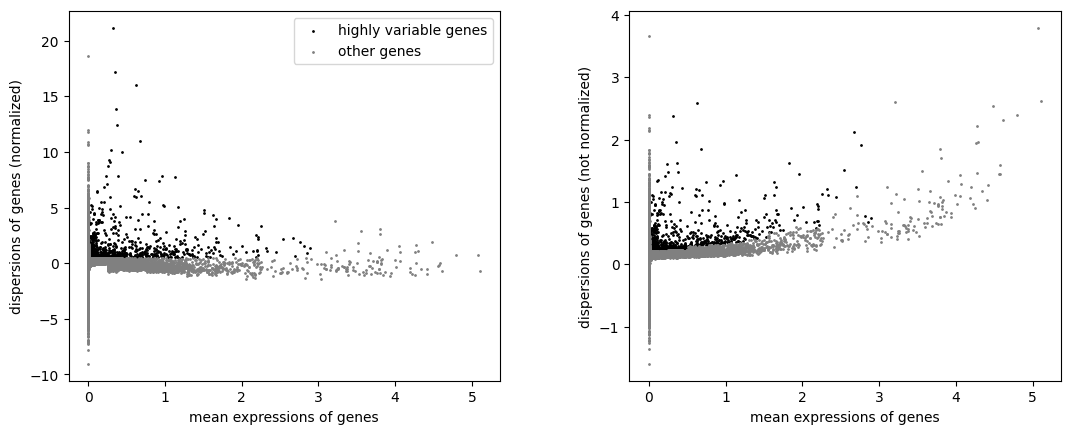

In [42]:
# Identify highly variable genes
print("Finding highly variable genes...")
sc.pp.highly_variable_genes(adata_singlets, min_mean=0.0125, max_mean=3, min_disp=0.5)

# Check how many HVGs were found
n_hvg = adata_singlets.var['highly_variable'].sum()
print(f"Found {n_hvg} highly variable genes out of {adata_singlets.shape[1]} total genes")

# Plot HVG selection
sc.pl.highly_variable_genes(adata_singlets)

In [43]:
# Keeping only highly variable genes
print(f"Before HVG filtering: {adata_singlets.shape}")
adata_singlets = adata_singlets[:, adata_singlets.var.highly_variable]
print(f"After HVG filtering: {adata_singlets.shape}")

# Save HVG-filtered dataset
adata_singlets.write_h5ad("/Users/prashammarfatia/Downloads/adata_singlets_hvg.h5ad")
print("HVG-filtered dataset saved")

Before HVG filtering: (214449, 29762)
After HVG filtering: (214449, 824)
HVG-filtered dataset saved


In [44]:
# Scale data to unit variance
sc.pp.scale(adata_singlets, max_value=10)
print("Data scaled")

Data scaled


PCA complete


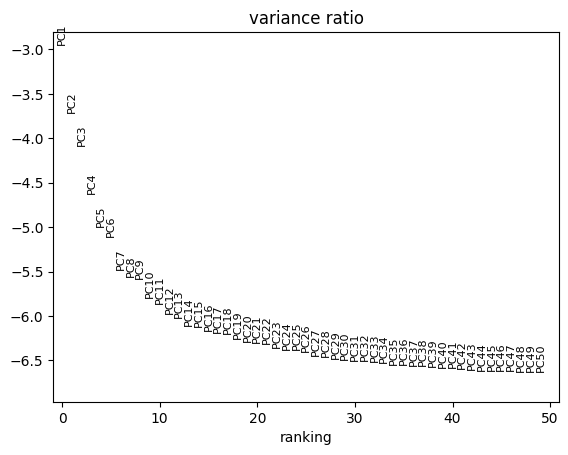

In [45]:
# Compute PCA
sc.tl.pca(adata_singlets, svd_solver='arpack')
print("PCA complete")

# Plot PCA variance ratio
sc.pl.pca_variance_ratio(adata_singlets, log=True, n_pcs=50)

In [46]:
# Compute the neighborhood graph
sc.pp.neighbors(adata_singlets, n_neighbors=10, n_pcs=40)
print("Neighborhood graph complete")

Neighborhood graph complete


In [47]:
# Compute UMAP
sc.tl.umap(adata_singlets)
print("UMAP complete")

# Save the final processed dataset
adata_singlets.write_h5ad("/Users/prashammarfatia/Downloads/adata_singlets_final.h5ad")
print("Final processed dataset saved")

UMAP complete
Final processed dataset saved


In [48]:
top_genes = ['safe-targeting', 'negative-control', 'TP53', 'SMAD3', 'ECM1', 'XPO7', 'ANKEF1']

# Check cell counts for these genes
for gene in top_genes:
    count = (adata_singlets.obs['Gene'] == gene).sum()
    print(f"{gene}: {count} cells")

# Create subset
adata_top_perturbations = adata_singlets[adata_singlets.obs['Gene'].isin(top_genes)].copy()
print(f"\nSubset shape: {adata_top_perturbations.shape}")

safe-targeting: 3284 cells
negative-control: 2222 cells
TP53: 215 cells
SMAD3: 128 cells
ECM1: 124 cells
XPO7: 108 cells
ANKEF1: 97 cells

Subset shape: (6178, 824)


<Figure size 1000x800 with 0 Axes>

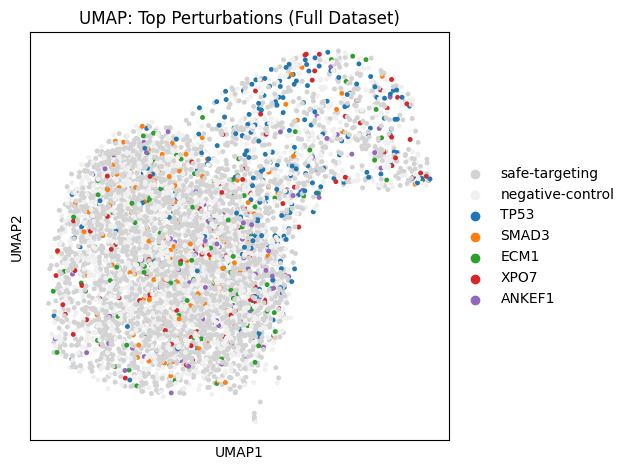

In [49]:
import matplotlib.pyplot as plt

# Your color scheme
color_map = {
    'safe-targeting': '#d3d3d3',
    'negative-control': '#f0f0f0', 
    'TP53': '#1f77b4',
    'SMAD3': '#ff7f0e',
    'ECM1': '#2ca02c',
    'XPO7': '#d62728',
    'ANKEF1': '#9467bd'
}

# Set up categorical
adata_top_perturbations.obs['Gene'] = adata_top_perturbations.obs['Gene'].astype('category')
adata_top_perturbations.obs['Gene'] = adata_top_perturbations.obs['Gene'].cat.set_categories(top_genes)

# Create palette
palette = [color_map[g] for g in adata_top_perturbations.obs['Gene'].cat.categories]

# Set figure size first
plt.figure(figsize=(10, 8))

# Plot UMAP
sc.pl.umap(
    adata_top_perturbations,
    color='Gene',
    palette=palette,
    size=50,
    legend_loc='right margin',
    title='UMAP: Top Perturbations (Full Dataset)',
    show=False
)

plt.tight_layout()
plt.show()

In [50]:
# Use proper thresholds for your large dataset
gene_counts = adata_singlets.obs['Gene'].value_counts()

# Much better thresholds
genes_50_plus = gene_counts[gene_counts >= 50]
genes_100_plus = gene_counts[gene_counts >= 100]

print(f"Genes with ≥50 cells: {len(genes_50_plus)}")
print(f"Genes with ≥100 cells: {len(genes_100_plus)}")

# Use top 50 perturbations with ≥100 cells + controls
top_robust_genes = genes_100_plus.head(50).index.tolist()
controls = ['safe-targeting', 'negative-control']
robust_analysis_genes = controls + [g for g in top_robust_genes if g not in controls]

print(f"\nRobust analysis set: {len(robust_analysis_genes)} genes")
print("Cell counts:")
for gene in robust_analysis_genes[:10]:
    count = (adata_singlets.obs['Gene'] == gene).sum()
    print(f"{gene}: {count} cells")

Genes with ≥50 cells: 2341
Genes with ≥100 cells: 489

Robust analysis set: 50 genes
Cell counts:
safe-targeting: 3284 cells
negative-control: 2222 cells
TP53: 215 cells
EGFL7: 177 cells
PVT1: 159 cells
CSDE1: 150 cells
PROX1: 148 cells
NME6: 144 cells
BRE: 141 cells
ARPC2: 141 cells


In [51]:
# Create a robust subset for DE analysis
adata_de = adata_singlets[adata_singlets.obs['Gene'].isin(robust_analysis_genes)].copy()

print(f"DE analysis dataset: {adata_de.shape}")
print(f"Total cells: {adata_de.shape[0]:,}")
print(f"Perturbations to analyze: {len(robust_analysis_genes)-2}")  # -2 for controls

# Set up control group
controls = ['safe-targeting', 'negative-control']
adata_de.obs['is_control'] = adata_de.obs['Gene'].isin(controls)

print(f"Control cells: {adata_de.obs['is_control'].sum():,}")
print(f"Perturbed cells: {(~adata_de.obs['is_control']).sum():,}")

DE analysis dataset: (11915, 824)
Total cells: 11,915
Perturbations to analyze: 48
Control cells: 5,506
Perturbed cells: 6,409


In [52]:
# Get complete results for all 48 perturbations
import pandas as pd

# Get the list of all 48 perturbation genes we analyzed
perturbation_genes = [g for g in robust_analysis_genes if g not in ['safe-targeting', 'negative-control']]
print(f"Analyzing results for all {len(perturbation_genes)} perturbations...")

# Initialize results storage
complete_results = []

# Loop through ALL 48 perturbations
for i, gene in enumerate(perturbation_genes):
    try:
        # Get DE results for this gene
        result = sc.get.rank_genes_groups_df(adata_de, group=gene)
        
        # Calculate summary statistics
        sig_genes = (result['pvals_adj'] < 0.05).sum()
        total_genes = len(result)
        
        # Get top effect sizes
        if len(result) > 0:
            max_logfc = result['logfoldchanges'].max()
            min_logfc = result['logfoldchanges'].min()
            top_gene = result.iloc[0]['names']
            top_pval = result.iloc[0]['pvals_adj']
            top_logfc = result.iloc[0]['logfoldchanges']
        else:
            max_logfc = min_logfc = top_logfc = 0
            top_gene = "None"
            top_pval = 1.0
        
        # Get cell count for this perturbation
        cell_count = (adata_de.obs['Gene'] == gene).sum()
        
        # Store results
        complete_results.append({
            'Gene': gene,
            'Cell_Count': cell_count,
            'Significant_Genes': sig_genes,
            'Total_Genes_Tested': total_genes,
            'Top_Gene': top_gene,
            'Top_LogFC': top_logfc,
            'Top_Pvalue': top_pval,
            'Max_LogFC': max_logfc,
            'Min_LogFC': min_logfc,
            'Has_Effect': sig_genes > 0
        })
        
        print(f"{i+1:2d}. {gene}: {sig_genes} significant genes (top: {top_gene}, logFC: {top_logfc:.2f})")
        
    except Exception as e:
        print(f"{i+1:2d}. {gene}: ERROR - {e}")
        complete_results.append({
            'Gene': gene,
            'Cell_Count': (adata_de.obs['Gene'] == gene).sum(),
            'Significant_Genes': 0,
            'Total_Genes_Tested': 0,
            'Top_Gene': "ERROR",
            'Top_LogFC': 0,
            'Top_Pvalue': 1.0,
            'Max_LogFC': 0,
            'Min_LogFC': 0,
            'Has_Effect': False
        })

# Convert to DataFrame for analysis
results_df = pd.DataFrame(complete_results)
results_df = results_df.sort_values('Significant_Genes', ascending=False)

print(f"\n" + "="*60)
print(f"COMPLETE SUMMARY OF ALL {len(results_df)} PERTURBATIONS")
print("="*60)

# Overall statistics
total_with_effects = (results_df['Significant_Genes'] > 0).sum()
success_rate = total_with_effects / len(results_df) * 100

print(f"Perturbations with detectable effects: {total_with_effects}/{len(results_df)} ({success_rate:.1f}%)")
print(f"Average significant genes per perturbation: {results_df['Significant_Genes'].mean():.1f}")
print(f"Median significant genes per perturbation: {results_df['Significant_Genes'].median():.1f}")

# Show top 20 most effective perturbations
print(f"\n TOP 20 MOST EFFECTIVE PERTURBATIONS:")
print(results_df.head(20)[['Gene', 'Cell_Count', 'Significant_Genes', 'Top_Gene', 'Top_LogFC']].to_string(index=False))

# Show breakdown by effect strength
print(f"\n BREAKDOWN BY EFFECT STRENGTH:")
ranges = [(0, 0), (1, 10), (11, 50), (51, 100), (101, 500), (501, float('inf'))]
for min_genes, max_genes in ranges:
    if max_genes == float('inf'):
        count = (results_df['Significant_Genes'] > min_genes).sum()
        print(f">{min_genes} significant genes: {count} perturbations")
    elif min_genes == max_genes:
        count = (results_df['Significant_Genes'] == min_genes).sum()
        print(f"{min_genes} significant genes: {count} perturbations")
    else:
        count = ((results_df['Significant_Genes'] >= min_genes) & 
                (results_df['Significant_Genes'] <= max_genes)).sum()
        print(f"{min_genes}-{max_genes} significant genes: {count} perturbations")

# Save complete results
output_path = "/Users/prashammarfatia/Downloads/complete_perturbation_results.csv"
results_df.to_csv(output_path, index=False)
print(f"\n Complete results saved to: {output_path}")

print(f"\n Full dataset ready for detailed analysis!")

Analyzing results for all 48 perturbations...
 1. TP53: ERROR - 'rank_genes_groups'
 2. EGFL7: ERROR - 'rank_genes_groups'
 3. PVT1: ERROR - 'rank_genes_groups'
 4. CSDE1: ERROR - 'rank_genes_groups'
 5. PROX1: ERROR - 'rank_genes_groups'
 6. NME6: ERROR - 'rank_genes_groups'
 7. BRE: ERROR - 'rank_genes_groups'
 8. ARPC2: ERROR - 'rank_genes_groups'
 9. LPIN3: ERROR - 'rank_genes_groups'
10. MLH3: ERROR - 'rank_genes_groups'
11. OR52A1: ERROR - 'rank_genes_groups'
12. TRIB1-TSS2: ERROR - 'rank_genes_groups'
13. TMEM222: ERROR - 'rank_genes_groups'
14. GSTT1: ERROR - 'rank_genes_groups'
15. CBX5-TSS2: ERROR - 'rank_genes_groups'
16. PRPH2: ERROR - 'rank_genes_groups'
17. CALCOCO1: ERROR - 'rank_genes_groups'
18. BAG6: ERROR - 'rank_genes_groups'
19. SMUG1: ERROR - 'rank_genes_groups'
20. GTF3A: ERROR - 'rank_genes_groups'
21. SPRED3: ERROR - 'rank_genes_groups'
22. MNT: ERROR - 'rank_genes_groups'
23. SMAD3: ERROR - 'rank_genes_groups'
24. ARG2: ERROR - 'rank_genes_groups'
25. QTRT1: E

Testing DE for TP53 vs controls...


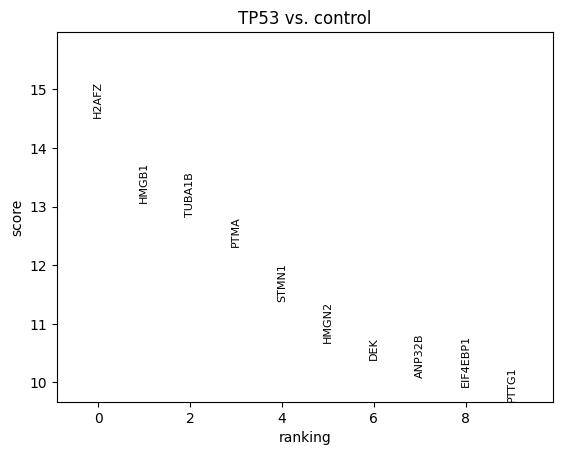

In [53]:
# Compare each perturbation vs all controls

# First, let's do a quick test with one perturbation
test_gene = 'TP53'
print(f"Testing DE for {test_gene} vs controls...")

# Create groups for comparison
adata_de.obs['comparison_group'] = 'other'
adata_de.obs.loc[adata_de.obs['Gene'] == test_gene, 'comparison_group'] = test_gene
adata_de.obs.loc[adata_de.obs['is_control'], 'comparison_group'] = 'control'

# Run DE analysis
sc.tl.rank_genes_groups(adata_de, 'comparison_group', groups=[test_gene], 
                       reference='control', method='wilcoxon')

# Check results
sc.pl.rank_genes_groups(adata_de, n_genes=10, sharey=False)

In [54]:
# Get the results as dataframe
result = sc.get.rank_genes_groups_df(adata_de, group=test_gene)
print(f"Top 10 genes affected by {test_gene} knockdown:")
print(result.head(10)[['names', 'logfoldchanges', 'pvals_adj']])

Top 10 genes affected by TP53 knockdown:
      names  logfoldchanges     pvals_adj
0     H2AFZ        1.291890  2.628740e-43
1     HMGB1        0.737271  5.533666e-35
2    TUBA1B        1.141514  8.093363e-34
3      PTMA        0.388878  3.607487e-31
4     STMN1        1.286132  2.207915e-26
5     HMGN2        0.937976  4.422549e-23
6       DEK        0.976653  8.328605e-22
7    ANP32B        0.800241  1.522910e-20
8  EIF4EBP1        0.749238  7.344561e-20
9     PTTG1        1.618492  7.920288e-19


In [55]:
# Test EGFL7 knockdown
test_gene2 = 'EGFL7'
print(f"Testing DE for {test_gene2} vs controls...")

adata_de.obs['comparison_group'] = 'other'
adata_de.obs.loc[adata_de.obs['Gene'] == test_gene2, 'comparison_group'] = test_gene2
adata_de.obs.loc[adata_de.obs['is_control'], 'comparison_group'] = 'control'

sc.tl.rank_genes_groups(adata_de, 'comparison_group', groups=[test_gene2], 
                       reference='control', method='wilcoxon')

result2 = sc.get.rank_genes_groups_df(adata_de, group=test_gene2)
print(f"Top 10 genes affected by {test_gene2} knockdown:")
print(result2.head(10)[['names', 'logfoldchanges', 'pvals_adj']])

Testing DE for EGFL7 vs controls...
Top 10 genes affected by EGFL7 knockdown:
     names  logfoldchanges     pvals_adj
0    EGFL7        1.681272  2.809183e-65
1      CD9        0.719753  9.438150e-24
2   AGPAT2        3.574299  3.413597e-21
3    H3F3B        0.657559  6.548663e-19
4     CD55        0.638327  1.672887e-10
5    ADAM9        0.693639  6.185063e-10
6    KRT18        0.540293  9.396746e-09
7   TUBA1B        0.720152  1.631515e-08
8     ACTB        0.248007  1.757494e-08
9  S100A10        0.293076  6.497251e-08


In [56]:
# Fix the categorical issue
print("Running DE analysis for all 48 perturbations...")

perturbation_genes = [g for g in robust_analysis_genes if g not in ['safe-targeting', 'negative-control']]

# Create new column without categorical constraints
adata_de.obs['perturbation'] = adata_de.obs['Gene'].astype(str).copy()
adata_de.obs.loc[adata_de.obs['is_control'], 'perturbation'] = 'control'

print(f"Perturbations to analyze: {len(perturbation_genes)}")
print("Sample perturbations:", perturbation_genes[:5])

# Run comprehensive DE analysis
sc.tl.rank_genes_groups(adata_de, 'perturbation', groups=perturbation_genes, 
                       reference='control', method='wilcoxon')

print(" Comprehensive DE analysis complete!")

Running DE analysis for all 48 perturbations...
Perturbations to analyze: 48
Sample perturbations: ['TP53', 'EGFL7', 'PVT1', 'CSDE1', 'PROX1']
 Comprehensive DE analysis complete!


In [57]:
# Get a summary of significant effects
print("DE Analysis Summary:")

significant_perturbations = 0
for gene in perturbation_genes[:10]:  # Check first 10
    try:
        result = sc.get.rank_genes_groups_df(adata_de, group=gene)
        sig_genes = (result['pvals_adj'] < 0.05).sum()
        print(f"{gene}: {sig_genes} significant genes")
        if sig_genes > 0:
            significant_perturbations += 1
    except:
        print(f"{gene}: Error in analysis")

print(f"\nPerturbations with detectable effects: {significant_perturbations}/10")

DE Analysis Summary:
TP53: 444 significant genes
EGFL7: 108 significant genes
PVT1: 39 significant genes
CSDE1: 7 significant genes
PROX1: 0 significant genes
NME6: 13 significant genes
BRE: 0 significant genes
ARPC2: 1 significant genes
LPIN3: 0 significant genes
MLH3: 0 significant genes

Perturbations with detectable effects: 6/10


In [58]:
import scanpy as sc
import matplotlib.pyplot as plt
import pandas as pd

# Reload the singlet dataset
adata_singlets = sc.read_h5ad("/Users/prashammarfatia/Downloads/adata_singlets_final.h5ad")
print(f"Reloaded: {adata_singlets.shape}")
print(f"Available columns: {adata_singlets.obs.columns.tolist()}")

Reloaded: (214449, 824)
Available columns: ['sample', 'batch_sample', 'Guide', 'Gene', 'UMI_count', 'Good_singlet', 'Multiplet', 'n_genes_by_counts', 'total_counts']


Knockdown Distribution Summary:
Total knockdown conditions: 2618
Total knockdown cells: 208,943
Mean cells per KD: 79.8
Median cells per KD: 82.0
Range: 2 - 215 cells


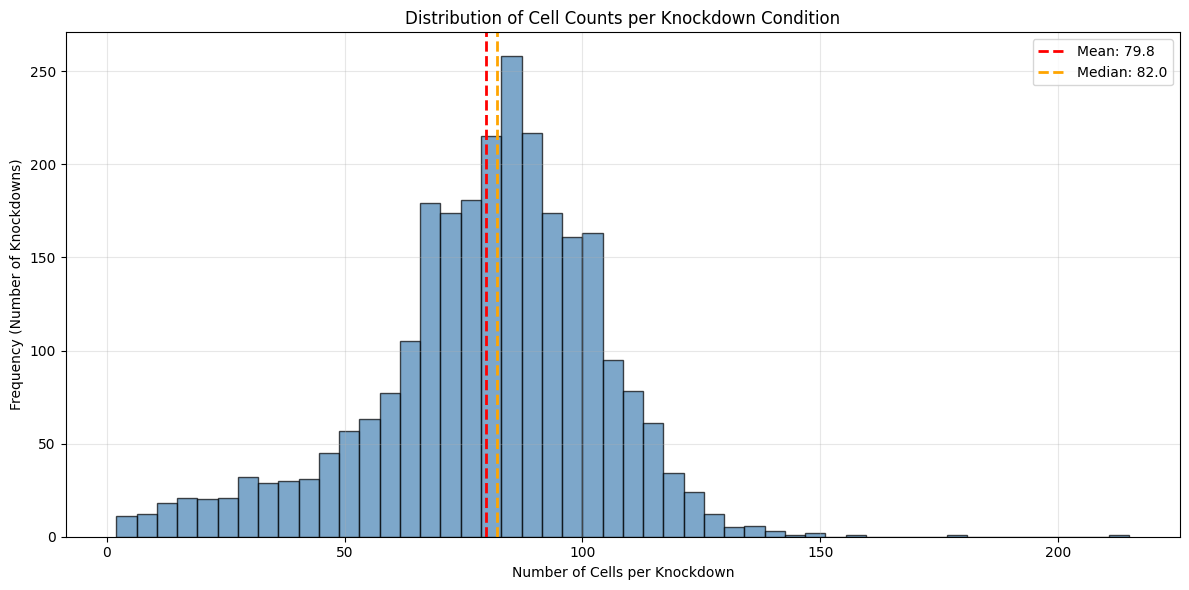


 Breakdown by Cell Count Ranges:
0-9 cells: 22 knockdowns
10-24 cells: 63 knockdowns
25-49 cells: 194 knockdowns
50-99 cells: 1852 knockdowns
100-199 cells: 486 knockdowns
200-499 cells: 1 knockdowns
≥500 cells: 0 knockdowns


In [59]:
# Get cell counts for all knockdowns (excluding controls)
gene_counts = adata_singlets.obs['Gene'].value_counts()

# Remove controls to focus on knockdowns only
controls = ['safe-targeting', 'negative-control']
knockdown_counts = gene_counts[~gene_counts.index.isin(controls)]

print(f"Knockdown Distribution Summary:")
print(f"Total knockdown conditions: {len(knockdown_counts)}")
print(f"Total knockdown cells: {knockdown_counts.sum():,}")
print(f"Mean cells per KD: {knockdown_counts.mean():.1f}")
print(f"Median cells per KD: {knockdown_counts.median():.1f}")
print(f"Range: {knockdown_counts.min()} - {knockdown_counts.max()} cells")

# Create histogram
plt.figure(figsize=(12, 6))
plt.hist(knockdown_counts.values, bins=50, alpha=0.7, color='steelblue', edgecolor='black')
plt.xlabel('Number of Cells per Knockdown')
plt.ylabel('Frequency (Number of Knockdowns)')
plt.title('Distribution of Cell Counts per Knockdown Condition')
plt.grid(True, alpha=0.3)

# Add summary statistics as text
plt.axvline(knockdown_counts.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {knockdown_counts.mean():.1f}')
plt.axvline(knockdown_counts.median(), color='orange', linestyle='--', linewidth=2, label=f'Median: {knockdown_counts.median():.1f}')
plt.legend()

plt.tight_layout()
plt.show()

# Show breakdown by cell count ranges
print(f"\n Breakdown by Cell Count Ranges:")
ranges = [(0, 10), (10, 25), (25, 50), (50, 100), (100, 200), (200, 500), (500, float('inf'))]
for min_cells, max_cells in ranges:
    if max_cells == float('inf'):
        count = (knockdown_counts >= min_cells).sum()
        print(f"≥{min_cells} cells: {count} knockdowns")
    else:
        count = ((knockdown_counts >= min_cells) & (knockdown_counts < max_cells)).sum()
        print(f"{min_cells}-{max_cells-1} cells: {count} knockdowns")

In [79]:
import numpy as np
from sklearn.cluster import KMeans
from collections import Counter

# Use the robust analysis genes (≥100 cells each)
test_genes = [g for g in robust_analysis_genes if g not in ['safe-targeting', 'negative-control']][:10]  # Test with top 10

print(" Calculating centroids for coherence test...")
print(f"Testing genes: {test_genes}")

# Calculate centroid for each perturbation
perturbation_centroids = []
perturbation_labels = []

for gene in test_genes:
    gene_cells = adata_de[adata_de.obs['Gene'] == gene]
    if len(gene_cells) >= 50:  # Ensure sufficient cells
        # Calculate centroid (average expression across all genes)
        centroid = np.mean(gene_cells.X.toarray(), axis=0)
        perturbation_centroids.append(centroid)
        perturbation_labels.append(gene)
        print(f"{gene}: {len(gene_cells)} cells → centroid calculated")

perturbation_centroids = np.array(perturbation_centroids)
print(f"\n Calculated {len(perturbation_centroids)} centroids")

 Calculating centroids for coherence test...
Testing genes: ['TP53', 'EGFL7', 'PVT1', 'CSDE1', 'PROX1', 'NME6', 'BRE', 'ARPC2', 'LPIN3', 'MLH3']
TP53: 215 cells → centroid calculated
EGFL7: 177 cells → centroid calculated
PVT1: 159 cells → centroid calculated
CSDE1: 150 cells → centroid calculated
PROX1: 148 cells → centroid calculated
NME6: 144 cells → centroid calculated
BRE: 141 cells → centroid calculated
ARPC2: 141 cells → centroid calculated
LPIN3: 139 cells → centroid calculated
MLH3: 138 cells → centroid calculated

 Calculated 10 centroids


In [80]:
# Get all cells from these perturbations
test_cells_mask = adata_de.obs['Gene'].isin(perturbation_labels)
test_adata = adata_de[test_cells_mask].copy()

print(f"Test dataset: {test_adata.shape}")
print("Cell distribution:")
for gene in perturbation_labels:
    count = (test_adata.obs['Gene'] == gene).sum()
    print(f"  {gene}: {count} cells")

# Initialize K-means with our centroids
n_clusters = len(perturbation_centroids)
kmeans = KMeans(n_clusters=n_clusters, init=perturbation_centroids, n_init=1, random_state=42)

# Check if data is sparse or dense and handle accordingly
if hasattr(test_adata.X, 'toarray'):
    X_data = test_adata.X.toarray()
else:
    X_data = test_adata.X

# Fit K-means
cluster_labels = kmeans.fit_predict(X_data)
test_adata.obs['kmeans_cluster'] = cluster_labels

print(f"\n K-means clustering complete with {n_clusters} clusters")

Test dataset: (1552, 824)
Cell distribution:
  TP53: 215 cells
  EGFL7: 177 cells
  PVT1: 159 cells
  CSDE1: 150 cells
  PROX1: 148 cells
  NME6: 144 cells
  BRE: 141 cells
  ARPC2: 141 cells
  LPIN3: 139 cells
  MLH3: 138 cells

 K-means clustering complete with 10 clusters


In [81]:
# Check cluster purity ( coherence metric)
print(" Coherence Test Results:")
print("=" * 50)

cluster_purity_scores = []

for i, gene in enumerate(perturbation_labels):
    # Get cells that should belong to this cluster (same perturbation)
    true_gene_cells = test_adata.obs['Gene'] == gene
    
    # Get cells actually assigned to this cluster
    assigned_to_cluster = test_adata.obs['kmeans_cluster'] == i
    
    # Calculate overlap
    correct_assignments = (true_gene_cells & assigned_to_cluster).sum()
    total_in_cluster = assigned_to_cluster.sum()
    total_true_cells = true_gene_cells.sum()
    
    # Purity metrics
    purity = correct_assignments / total_in_cluster if total_in_cluster > 0 else 0
    recall = correct_assignments / total_true_cells if total_true_cells > 0 else 0
    
    cluster_purity_scores.append(purity)
    
    print(f"{gene} (Cluster {i}):")
    print(f"  Purity: {purity:.3f} ({correct_assignments}/{total_in_cluster} cells are correct)")
    print(f"  Recall: {recall:.3f} ({correct_assignments}/{total_true_cells} cells captured)")
    
    # Show what else is in this cluster
    cluster_composition = test_adata.obs[assigned_to_cluster]['Gene'].value_counts()
    print(f"  Cluster composition: {dict(cluster_composition.head(3))}")
    print()

# Overall coherence score
overall_coherence = np.mean(cluster_purity_scores)
print(f" Overall Coherence Score: {overall_coherence:.3f}")
print(f"Interpretation:")
if overall_coherence > 0.7:
    print("   EXCELLENT: Perturbations cluster together well")
elif overall_coherence > 0.5:
    print("   GOOD: Moderate clustering of perturbations")
elif overall_coherence > 0.3:
    print("   FAIR: Some clustering but noisy")
else:
    print("   POOR: Perturbations are scattered - data quality concerns")

 Coherence Test Results:
TP53 (Cluster 0):
  Purity: 0.376 (32/85 cells are correct)
  Recall: 0.149 (32/215 cells captured)
  Cluster composition: {'TP53': np.int64(32), 'CSDE1': np.int64(13), 'EGFL7': np.int64(12)}

EGFL7 (Cluster 1):
  Purity: 0.189 (17/90 cells are correct)
  Recall: 0.096 (17/177 cells captured)
  Cluster composition: {'TP53': np.int64(38), 'EGFL7': np.int64(17), 'LPIN3': np.int64(7)}

PVT1 (Cluster 2):
  Purity: 0.280 (46/164 cells are correct)
  Recall: 0.289 (46/159 cells captured)
  Cluster composition: {'PVT1': np.int64(46), 'MLH3': np.int64(21), 'CSDE1': np.int64(20)}

CSDE1 (Cluster 3):
  Purity: 0.153 (17/111 cells are correct)
  Recall: 0.113 (17/150 cells captured)
  Cluster composition: {'TP53': np.int64(42), 'CSDE1': np.int64(17), 'EGFL7': np.int64(16)}

PROX1 (Cluster 4):
  Purity: 0.135 (14/104 cells are correct)
  Recall: 0.095 (14/148 cells captured)
  Cluster composition: {'ARPC2': np.int64(15), 'PROX1': np.int64(14), 'BRE': np.int64(11)}

NME6 (C

In [62]:
# Check target gene knockdown for all 48 perturbations
target_knockdown_results = []

for gene in perturbation_genes:
    try:
        # Get DE results for this perturbation
        result = sc.get.rank_genes_groups_df(adata_de, group=gene)
        
        # Look for the target gene itself in the results
        target_row = result[result['names'] == gene]
        
        if len(target_row) > 0:
            target_logfc = target_row.iloc[0]['logfoldchanges']
            target_pval = target_row.iloc[0]['pvals_adj']
            is_significant = target_pval < 0.05
            is_knocked_down = target_logfc < 0  # Negative = reduced expression
            
            target_knockdown_results.append({
                'Gene': gene,
                'Target_Detected': True,
                'Target_LogFC': target_logfc,
                'Target_Pvalue': target_pval,
                'Is_Significant': is_significant,
                'Is_Knocked_Down': is_knocked_down,
                'Cell_Count': (adata_de.obs['Gene'] == gene).sum()
            })
        else:
            # Target gene not found in results
            target_knockdown_results.append({
                'Gene': gene,
                'Target_Detected': False,
                'Target_LogFC': None,
                'Target_Pvalue': None,
                'Is_Significant': False,
                'Is_Knocked_Down': False,
                'Cell_Count': (adata_de.obs['Gene'] == gene).sum()
            })
            
    except Exception as e:
        target_knockdown_results.append({
            'Gene': gene,
            'Target_Detected': False,
            'Target_LogFC': None,
            'Target_Pvalue': None,
            'Is_Significant': False,
            'Is_Knocked_Down': False,
            'Cell_Count': (adata_de.obs['Gene'] == gene).sum()
        })

# Convert to DataFrame
knockdown_df = pd.DataFrame(target_knockdown_results)

# Summary statistics
total_perturbations = len(knockdown_df)
targets_detected = knockdown_df['Target_Detected'].sum()
targets_significant = knockdown_df['Is_Significant'].sum()
targets_knocked_down = knockdown_df['Is_Knocked_Down'].sum()

print(" TARGET GENE KNOCKDOWN EFFICACY ANALYSIS")
print("=" * 50)
print(f"Total perturbations analyzed: {total_perturbations}")
print(f"Target genes detected in results: {targets_detected}/{total_perturbations} ({targets_detected/total_perturbations*100:.1f}%)")
print(f"Target genes significantly changed: {targets_significant}/{total_perturbations} ({targets_significant/total_perturbations*100:.1f}%)")
print(f"Target genes successfully knocked down: {targets_knocked_down}/{total_perturbations} ({targets_knocked_down/total_perturbations*100:.1f}%)")

# Show successful knockdowns
successful_kd = knockdown_df[knockdown_df['Is_Knocked_Down'] == True].sort_values('Target_LogFC')
print(f"\n SUCCESSFUL KNOCKDOWNS (target gene reduced):")
if len(successful_kd) > 0:
    for _, row in successful_kd.iterrows():
        print(f"{row['Gene']}: {row['Target_LogFC']:.3f} log2FC, p-adj = {row['Target_Pvalue']:.2e}")
else:
    print("No successful knockdowns detected")

# Show failed knockdowns (target gene not reduced)
failed_kd = knockdown_df[knockdown_df['Target_Detected'] == True][knockdown_df['Is_Knocked_Down'] == False].sort_values('Target_LogFC', ascending=False)
print(f"\n FAILED/UNEXPECTED KNOCKDOWNS (target gene increased or unchanged):")
if len(failed_kd) > 0:
    for _, row in failed_kd.head(10).iterrows():
        print(f"{row['Gene']}: {row['Target_LogFC']:.3f} log2FC, p-adj = {row['Target_Pvalue']:.2e}")

# Save results
knockdown_df.to_csv("/Users/prashammarfatia/Downloads/target_knockdown_efficacy.csv", index=False)
print(f"\n Results saved to: target_knockdown_efficacy.csv")

 TARGET GENE KNOCKDOWN EFFICACY ANALYSIS
Total perturbations analyzed: 48
Target genes detected in results: 37/48 (77.1%)
Target genes significantly changed: 8/48 (16.7%)
Target genes successfully knocked down: 33/48 (68.8%)

 SUCCESSFUL KNOCKDOWNS (target gene reduced):
LPIN3: -23.778 log2FC, p-adj = 1.00e+00
GSTO2: -22.434 log2FC, p-adj = 1.00e+00
PRPH2: -19.536 log2FC, p-adj = 1.00e+00
PROX1: -18.257 log2FC, p-adj = 1.00e+00
ECM1: -2.594 log2FC, p-adj = 1.00e+00
ARG2: -1.736 log2FC, p-adj = 1.00e+00
MLH3: -1.681 log2FC, p-adj = 1.00e+00
DNALI1: -1.502 log2FC, p-adj = 1.00e+00
PDLIM7: -1.501 log2FC, p-adj = 1.51e-03
QTRT1: -1.495 log2FC, p-adj = 1.00e+00
GTF3A: -1.426 log2FC, p-adj = 8.55e-12
SLC2A6: -1.425 log2FC, p-adj = 1.00e+00
PCMTD2: -1.299 log2FC, p-adj = 1.00e+00
CSDE1: -1.278 log2FC, p-adj = 2.17e-13
NME6: -1.223 log2FC, p-adj = 1.00e+00
KDELR2: -1.186 log2FC, p-adj = 3.40e-08
TP53: -1.121 log2FC, p-adj = 4.12e-03
ARPC2: -1.076 log2FC, p-adj = 1.85e-14
HINT3: -0.957 log2FC, 

In [63]:
# Re-analyze target knockdown using RAW p-values (no FDR correction)
target_knockdown_raw = []

for gene in perturbation_genes:
    try:
        result = sc.get.rank_genes_groups_df(adata_de, group=gene)
        target_row = result[result['names'] == gene]
        
        if len(target_row) > 0:
            target_logfc = target_row.iloc[0]['logfoldchanges']
            target_pval_raw = target_row.iloc[0]['pvals']        # RAW p-value
            target_pval_adj = target_row.iloc[0]['pvals_adj']    # FDR corrected
            
            is_significant_raw = target_pval_raw < 0.05
            is_significant_adj = target_pval_adj < 0.05
            is_knocked_down = target_logfc < 0
            
            target_knockdown_raw.append({
                'Gene': gene,
                'Target_LogFC': target_logfc,
                'Raw_Pvalue': target_pval_raw,
                'FDR_Pvalue': target_pval_adj,
                'Significant_Raw': is_significant_raw,
                'Significant_FDR': is_significant_adj,
                'Is_Knocked_Down': is_knocked_down
            })
        else:
            target_knockdown_raw.append({
                'Gene': gene,
                'Target_LogFC': None,
                'Raw_Pvalue': None,
                'FDR_Pvalue': None,
                'Significant_Raw': False,
                'Significant_FDR': False,
                'Is_Knocked_Down': False
            })
            
    except Exception as e:
        print(f"Error processing {gene}: {e}")

# Convert to DataFrame
raw_df = pd.DataFrame(target_knockdown_raw)

# Summary statistics
targets_detected = len(raw_df[raw_df['Target_LogFC'].notna()])
targets_knocked_down = len(raw_df[raw_df['Is_Knocked_Down'] == True])
targets_sig_raw = len(raw_df[raw_df['Significant_Raw'] == True])
targets_sig_fdr = len(raw_df[raw_df['Significant_FDR'] == True])

print(" TARGET KNOCKDOWN: RAW vs FDR CORRECTED P-VALUES")
print("=" * 60)
print(f"Targets detected: {targets_detected}/48")
print(f"Targets knocked down (reduced expression): {targets_knocked_down}/48 ({targets_knocked_down/48*100:.1f}%)")
print(f"Significant knockdowns (raw p < 0.05): {targets_sig_raw}/48 ({targets_sig_raw/48*100:.1f}%)")
print(f"Significant knockdowns (FDR p < 0.05): {targets_sig_fdr}/48 ({targets_sig_fdr/48*100:.1f}%)")

print(f"\n SUCCESSFUL KNOCKDOWNS (reduced + raw p < 0.05):")
successful_raw = raw_df[(raw_df['Is_Knocked_Down'] == True) & (raw_df['Significant_Raw'] == True)].sort_values('Target_LogFC')
for _, row in successful_raw.iterrows():
    print(f"{row['Gene']}: {row['Target_LogFC']:.2f} log2FC, raw p = {row['Raw_Pvalue']:.2e}")

print(f"\n For context - what FDR correction did:")
print(f"Raw p-values < 0.05: {targets_sig_raw} targets")
print(f"FDR p-values < 0.05: {targets_sig_fdr} targets")
print(f"FDR correction removed: {targets_sig_raw - targets_sig_fdr} targets from significance")

 TARGET KNOCKDOWN: RAW vs FDR CORRECTED P-VALUES
Targets detected: 37/48
Targets knocked down (reduced expression): 33/48 (68.8%)
Significant knockdowns (raw p < 0.05): 13/48 (27.1%)
Significant knockdowns (FDR p < 0.05): 8/48 (16.7%)

 SUCCESSFUL KNOCKDOWNS (reduced + raw p < 0.05):
MLH3: -1.68 log2FC, raw p = 2.12e-02
DNALI1: -1.50 log2FC, raw p = 1.39e-02
PDLIM7: -1.50 log2FC, raw p = 5.08e-08
QTRT1: -1.49 log2FC, raw p = 3.29e-02
GTF3A: -1.43 log2FC, raw p = 2.87e-16
CSDE1: -1.28 log2FC, raw p = 7.30e-18
KDELR2: -1.19 log2FC, raw p = 1.14e-12
TP53: -1.12 log2FC, raw p = 3.74e-05
ARPC2: -1.08 log2FC, raw p = 6.22e-19
C18orf32: -0.94 log2FC, raw p = 2.06e-06
PVT1: -0.74 log2FC, raw p = 1.36e-05
BABAM1: -0.45 log2FC, raw p = 2.95e-02

 For context - what FDR correction did:
Raw p-values < 0.05: 13 targets
FDR p-values < 0.05: 8 targets
FDR correction removed: 5 targets from significance


Collected raw p-values for 37 target genes


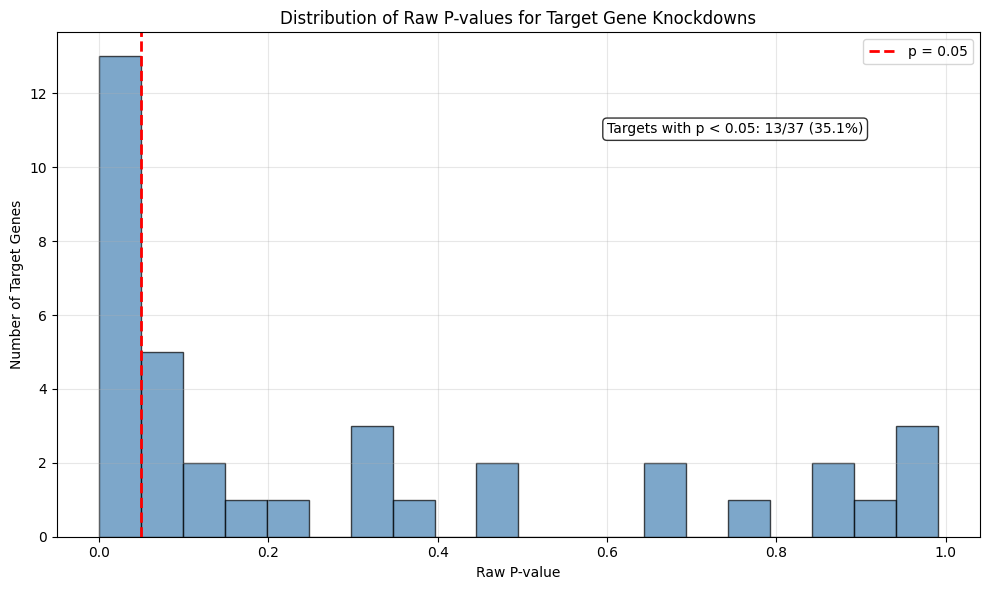


P-value Summary:
Mean p-value: 0.296
Median p-value: 0.100
P-values < 0.05: 13/37
P-values < 0.01: 9/37
P-values < 0.001: 9/37


In [64]:
import matplotlib.pyplot as plt
import numpy as np

# Extract raw p-values for all detected target genes
target_pvalues = []
target_genes = []

for gene in perturbation_genes:
    try:
        result = sc.get.rank_genes_groups_df(adata_de, group=gene)
        target_row = result[result['names'] == gene]
        
        if len(target_row) > 0:
            raw_p = target_row.iloc[0]['pvals']
            target_pvalues.append(raw_p)
            target_genes.append(gene)
        
    except Exception as e:
        continue

print(f"Collected raw p-values for {len(target_pvalues)} target genes")

# Create histogram
plt.figure(figsize=(10, 6))
plt.hist(target_pvalues, bins=20, alpha=0.7, color='steelblue', edgecolor='black')
plt.xlabel('Raw P-value')
plt.ylabel('Number of Target Genes')
plt.title('Distribution of Raw P-values for Target Gene Knockdowns')
plt.grid(True, alpha=0.3)

# Add significance threshold line
plt.axvline(x=0.05, color='red', linestyle='--', linewidth=2, label='p = 0.05')
plt.legend()

# Add summary text
significant_count = sum(1 for p in target_pvalues if p < 0.05)
plt.text(0.6, max(plt.ylim()) * 0.8, 
         f'Targets with p < 0.05: {significant_count}/{len(target_pvalues)} ({significant_count/len(target_pvalues)*100:.1f}%)',
         bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

plt.tight_layout()
plt.show()

# Print summary statistics
print(f"\nP-value Summary:")
print(f"Mean p-value: {np.mean(target_pvalues):.3f}")
print(f"Median p-value: {np.median(target_pvalues):.3f}")
print(f"P-values < 0.05: {significant_count}/{len(target_pvalues)}")
print(f"P-values < 0.01: {sum(1 for p in target_pvalues if p < 0.01)}/{len(target_pvalues)}")
print(f"P-values < 0.001: {sum(1 for p in target_pvalues if p < 0.001)}/{len(target_pvalues)}")

Complete dataset: 48 target genes out of 48 analyzed


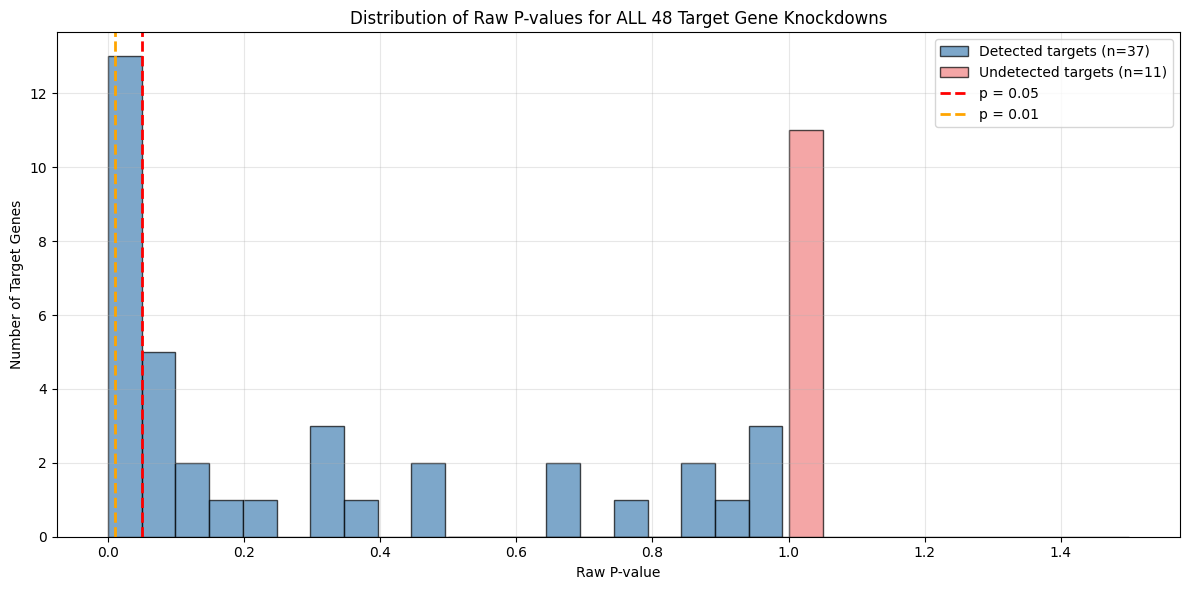


 COMPLETE P-VALUE ANALYSIS (ALL 48 TARGETS):
Total targets analyzed: 48
Targets detected in results: 37
Targets not detected: 11

P-value thresholds:
P < 0.05: 13/48 (27.1%)
P < 0.01: 9/48 (18.8%)
P < 0.001: 9/48 (18.8%)

Summary statistics:
Mean p-value: 0.457
Median p-value: 0.307
Min p-value: 9.44e-70
Max p-value: 1.000

 ALL RAW P-VALUES:
TP53: 3.74e-05 (Detected)
EGFL7: 9.44e-70 (Detected)
PVT1: 1.36e-05 (Detected)
CSDE1: 7.30e-18 (Detected)
PROX1: 9.91e-01 (Detected)
NME6: 2.14e-01 (Detected)
BRE: 1.0 (Not Detected)
ARPC2: 6.22e-19 (Detected)
LPIN3: 6.47e-01 (Detected)
MLH3: 2.12e-02 (Detected)
OR52A1: 9.10e-01 (Detected)
TRIB1-TSS2: 1.0 (Not Detected)
TMEM222: 4.83e-01 (Detected)
GSTT1: 1.0 (Not Detected)
CBX5-TSS2: 1.0 (Not Detected)
PRPH2: 9.83e-01 (Detected)
CALCOCO1: 9.62e-02 (Detected)
BAG6: 9.98e-02 (Detected)
SMUG1: 3.05e-01 (Detected)
GTF3A: 2.87e-16 (Detected)
SPRED3: 3.02e-01 (Detected)
MNT: 7.70e-01 (Detected)
SMAD3: 1.40e-01 (Detected)
ARG2: 4.48e-01 (Detected)
QTRT

In [65]:
import matplotlib.pyplot as plt
import numpy as np

# Extract raw p-values for ALL 48 target genes (including undetected ones)
all_target_pvalues = []
all_target_genes = []
detection_status = []

for gene in perturbation_genes:
    try:
        result = sc.get.rank_genes_groups_df(adata_de, group=gene)
        target_row = result[result['names'] == gene]
        
        if len(target_row) > 0:
            # Target gene detected in results
            raw_p = target_row.iloc[0]['pvals']
            all_target_pvalues.append(raw_p)
            all_target_genes.append(gene)
            detection_status.append('Detected')
        else:
            # Target gene not detected - assign p = 1.0 (worst possible)
            all_target_pvalues.append(1.0)
            all_target_genes.append(gene)
            detection_status.append('Not Detected')
        
    except Exception as e:
        # Error in processing - assign p = 1.0
        all_target_pvalues.append(1.0)
        all_target_genes.append(gene)
        detection_status.append('Error')

print(f"Complete dataset: {len(all_target_pvalues)} target genes out of 48 analyzed")

# Create histogram
plt.figure(figsize=(12, 6))

# Plot histogram with different colors for detected vs undetected
detected_pvals = [p for p, status in zip(all_target_pvalues, detection_status) if status == 'Detected']
undetected_pvals = [p for p, status in zip(all_target_pvalues, detection_status) if status != 'Detected']

plt.hist(detected_pvals, bins=20, alpha=0.7, color='steelblue', 
         label=f'Detected targets (n={len(detected_pvals)})', edgecolor='black')
plt.hist(undetected_pvals, bins=20, alpha=0.7, color='lightcoral', 
         label=f'Undetected targets (n={len(undetected_pvals)})', edgecolor='black')

plt.xlabel('Raw P-value')
plt.ylabel('Number of Target Genes')
plt.title('Distribution of Raw P-values for ALL 48 Target Gene Knockdowns')
plt.grid(True, alpha=0.3)

# Add significance threshold lines
plt.axvline(x=0.05, color='red', linestyle='--', linewidth=2, label='p = 0.05')
plt.axvline(x=0.01, color='orange', linestyle='--', linewidth=2, label='p = 0.01')
plt.legend()

plt.tight_layout()
plt.show()

# Print comprehensive summary
print(f"\n COMPLETE P-VALUE ANALYSIS (ALL 48 TARGETS):")
print("=" * 50)
print(f"Total targets analyzed: {len(all_target_pvalues)}")
print(f"Targets detected in results: {len(detected_pvals)}")
print(f"Targets not detected: {len(undetected_pvals)}")

print(f"\nP-value thresholds:")
p_005 = sum(1 for p in all_target_pvalues if p < 0.05)
p_001 = sum(1 for p in all_target_pvalues if p < 0.01)
p_0001 = sum(1 for p in all_target_pvalues if p < 0.001)

print(f"P < 0.05: {p_005}/48 ({p_005/48*100:.1f}%)")
print(f"P < 0.01: {p_001}/48 ({p_001/48*100:.1f}%)")
print(f"P < 0.001: {p_0001}/48 ({p_0001/48*100:.1f}%)")

print(f"\nSummary statistics:")
print(f"Mean p-value: {np.mean(all_target_pvalues):.3f}")
print(f"Median p-value: {np.median(all_target_pvalues):.3f}")
print(f"Min p-value: {np.min(all_target_pvalues):.2e}")
print(f"Max p-value: {np.max(all_target_pvalues):.3f}")

# Show the actual p-values for reference
print(f"\n ALL RAW P-VALUES:")
for gene, pval, status in zip(all_target_genes, all_target_pvalues, detection_status):
    if pval < 1.0:
        print(f"{gene}: {pval:.2e} ({status})")
    else:
        print(f"{gene}: {pval:.1f} ({status})")

In [66]:
# Focus on high-confidence knockdowns with downstream effects
high_confidence_targets = ['TP53', 'PVT1', 'GTF3A', 'CSDE1', 'KDELR2']

print(" HIGH-CONFIDENCE KNOCKDOWN → DOWNSTREAM ANALYSIS")
print("=" * 60)

for target in high_confidence_targets:
    print(f"\n {target} PATHWAY ANALYSIS:")
    
    # Get DE results for this target
    result = sc.get.rank_genes_groups_df(adata_de, group=target)
    
    # Target gene knockdown confirmation
    target_row = result[result['names'] == target]
    if len(target_row) > 0:
        target_fc = target_row.iloc[0]['logfoldchanges']
        target_p = target_row.iloc[0]['pvals_adj']
        print(f"   Target knockdown: {target_fc:.2f} log2FC, p-adj = {target_p:.2e}")
    
    # Top downstream effects (excluding target gene itself)
    downstream = result[result['names'] != target]
    significant_downstream = downstream[downstream['pvals_adj'] < 0.05]
    
    print(f"   Downstream genes affected: {len(significant_downstream)}")
    print(f"   Top 5 downstream effects:")
    
    for _, row in significant_downstream.head(5).iterrows():
        print(f"     {row['names']}: {row['logfoldchanges']:.2f} log2FC, p-adj = {row['pvals_adj']:.2e}")
    
    # Save detailed results for this pathway
    pathway_file = f"/Users/prashammarfatia/Downloads/{target}_pathway_analysis.csv"
    significant_downstream.to_csv(pathway_file, index=False)
    print(f"   Saved to: {target}_pathway_analysis.csv")

print(f"\n PATHWAY ANALYSIS COMPLETE")
print("Focus on these high-confidence target→downstream relationships for mechanistic insights")

 HIGH-CONFIDENCE KNOCKDOWN → DOWNSTREAM ANALYSIS

 TP53 PATHWAY ANALYSIS:
   Target knockdown: -1.12 log2FC, p-adj = 4.12e-03
   Downstream genes affected: 443
   Top 5 downstream effects:
     H2AFZ: 1.29 log2FC, p-adj = 2.63e-43
     HMGB1: 0.74 log2FC, p-adj = 5.53e-35
     TUBA1B: 1.14 log2FC, p-adj = 8.09e-34
     PTMA: 0.39 log2FC, p-adj = 3.61e-31
     STMN1: 1.29 log2FC, p-adj = 2.21e-26
   Saved to: TP53_pathway_analysis.csv

 PVT1 PATHWAY ANALYSIS:
   Target knockdown: -0.74 log2FC, p-adj = 1.83e-02
   Downstream genes affected: 38
   Top 5 downstream effects:
     RPL26: 0.15 log2FC, p-adj = 8.61e-05
     EEF1B2: 0.20 log2FC, p-adj = 2.64e-03
     RPS2: 0.12 log2FC, p-adj = 2.89e-03
     MT-ND6: 0.52 log2FC, p-adj = 7.61e-03
     EEF1A1: 0.10 log2FC, p-adj = 7.76e-03
   Saved to: PVT1_pathway_analysis.csv

 GTF3A PATHWAY ANALYSIS:
   Target knockdown: -1.43 log2FC, p-adj = 8.55e-12
   Downstream genes affected: 6
   Top 5 downstream effects:
     RPL10A: -0.23 log2FC, p-adj 

In [67]:
# Analyze pathway edge signs for all high-confidence targets
import pandas as pd

def analyze_pathway_signs(target_gene):
    """Analyze the signs of target→downstream relationships"""
    
    result = sc.get.rank_genes_groups_df(adata_de, group=target_gene)
    
    # Get target knockdown direction
    target_row = result[result['names'] == target_gene]
    target_fc = target_row.iloc[0]['logfoldchanges'] if len(target_row) > 0 else 0
    
    # Downstream genes (excluding target)
    downstream = result[result['names'] != target_gene]
    significant_downstream = downstream[downstream['pvals_adj'] < 0.05]
    
    # Classify edge signs
    edge_analysis = []
    
    for _, row in significant_downstream.iterrows():
        downstream_gene = row['names']
        downstream_fc = row['logfoldchanges']
        downstream_p = row['pvals_adj']
        
        # Determine edge sign
        if downstream_fc > 0:
            edge_sign = "Inhibitory"  # Target normally suppresses this gene
            edge_symbol = "⊣"
        else:
            edge_sign = "Activating"  # Target normally promotes this gene  
            edge_symbol = "→"
        
        edge_analysis.append({
            'Target': target_gene,
            'Downstream': downstream_gene,
            'Target_LogFC': target_fc,
            'Downstream_LogFC': downstream_fc,
            'Downstream_Pvalue': downstream_p,
            'Edge_Type': edge_sign,
            'Edge_Symbol': edge_symbol,
            'Pathway': f"{target_gene} {edge_symbol} {downstream_gene}"
        })
    
    return pd.DataFrame(edge_analysis)

# Analyze all high-confidence pathways
high_confidence_targets = ['TP53', 'PVT1', 'GTF3A', 'CSDE1', 'KDELR2']
all_pathway_edges = []

print(" PATHWAY EDGE SIGN ANALYSIS")
print("=" * 60)

for target in high_confidence_targets:
    edge_df = analyze_pathway_signs(target)
    all_pathway_edges.append(edge_df)
    
    # Summary statistics
    activating = (edge_df['Edge_Type'] == 'Activating').sum()
    inhibitory = (edge_df['Edge_Type'] == 'Inhibitory').sum()
    total = len(edge_df)
    
    print(f"\n📍 {target} EDGE ANALYSIS:")
    print(f"   Target knockdown: {edge_df.iloc[0]['Target_LogFC']:.2f} log2FC")
    print(f"   Total downstream edges: {total}")
    print(f"   Activating edges (→): {activating} ({activating/total*100:.1f}%)")
    print(f"   Inhibitory edges (⊣): {inhibitory} ({inhibitory/total*100:.1f}%)")
    
    print(f"   Top 5 relationships:")
    for _, row in edge_df.head(5).iterrows():
        print(f"     {row['Pathway']}: {row['Downstream_LogFC']:.2f} log2FC")

# Combine all pathways
combined_edges = pd.concat(all_pathway_edges, ignore_index=True)

# Overall statistics
total_edges = len(combined_edges)
total_activating = (combined_edges['Edge_Type'] == 'Activating').sum()
total_inhibitory = (combined_edges['Edge_Type'] == 'Inhibitory').sum()

print(f"\n OVERALL PATHWAY NETWORK:")
print(f"Total confirmed edges: {total_edges}")
print(f"Activating edges (→): {total_activating} ({total_activating/total_edges*100:.1f}%)")
print(f"Inhibitory edges (⊣): {total_inhibitory} ({total_inhibitory/total_edges*100:.1f}%)")

# Save complete edge list
edge_file = "/Users/prashammarfatia/Downloads/pathway_edge_signs.csv"
combined_edges.to_csv(edge_file, index=False)
print(f"\n Complete edge list saved to: pathway_edge_signs.csv")

print(f"\n NETWORK INTERPRETATION:")
print("→ = Target normally PROMOTES downstream gene (activating)")
print("⊣ = Target normally SUPPRESSES downstream gene (inhibitory)")

 PATHWAY EDGE SIGN ANALYSIS

📍 TP53 EDGE ANALYSIS:
   Target knockdown: -1.12 log2FC
   Total downstream edges: 443
   Activating edges (→): 152 (34.3%)
   Inhibitory edges (⊣): 291 (65.7%)
   Top 5 relationships:
     TP53 ⊣ H2AFZ: 1.29 log2FC
     TP53 ⊣ HMGB1: 0.74 log2FC
     TP53 ⊣ TUBA1B: 1.14 log2FC
     TP53 ⊣ PTMA: 0.39 log2FC
     TP53 ⊣ STMN1: 1.29 log2FC

📍 PVT1 EDGE ANALYSIS:
   Target knockdown: -0.74 log2FC
   Total downstream edges: 38
   Activating edges (→): 21 (55.3%)
   Inhibitory edges (⊣): 17 (44.7%)
   Top 5 relationships:
     PVT1 ⊣ RPL26: 0.15 log2FC
     PVT1 ⊣ EEF1B2: 0.20 log2FC
     PVT1 ⊣ RPS2: 0.12 log2FC
     PVT1 ⊣ MT-ND6: 0.52 log2FC
     PVT1 ⊣ EEF1A1: 0.10 log2FC

📍 GTF3A EDGE ANALYSIS:
   Target knockdown: -1.43 log2FC
   Total downstream edges: 6
   Activating edges (→): 6 (100.0%)
   Inhibitory edges (⊣): 0 (0.0%)
   Top 5 relationships:
     GTF3A → RPL10A: -0.23 log2FC
     GTF3A → VIM: -0.18 log2FC
     GTF3A → RPL12: -0.19 log2FC
     GTF3A →

In [68]:
adata_singlets.write_h5ad("/Users/prashammarfatia/Downloads/adata_singlets_backup.h5ad")
adata_de.write_h5ad("/Users/prashammarfatia/Downloads/adata_de_backup.h5ad")
print("Data saved")

Data saved


In [69]:
import scanpy as sc
import pandas as pd
import numpy as np

# Reload data
adata_singlets = sc.read_h5ad("/Users/prashammarfatia/Downloads/adata_singlets_backup.h5ad")
adata_de = sc.read_h5ad("/Users/prashammarfatia/Downloads/adata_de_backup.h5ad")

# Recreate key lists
perturbation_genes = [g for g in adata_de.obs['Gene'].unique() if g not in ['safe-targeting', 'negative-control']]
fdr_significant_targets = ['TP53', 'PVT1', 'GTF3A', 'CSDE1', 'KDELR2', 'ARPC2', 'PDLIM7', 'C18orf32']

print(" Ready to continue")

 Ready to continue


TARGET KNOCKDOWN VALIDATION ANALYSIS
Goal: Understand if experiments worked & flag feedback loops

 POPULATION ANALYSIS 
Total targets analyzed: 48
Successful knockdowns: 33 (68.8%)
Potential feedback loops: 4 (8.3%)
Target not detected: 11 (22.9%)

 FEEDBACK LOOPS TO FLAG):
Targets that INCREASED after knockdown (potential feedback):
  EGFL7: +1.68 log2FC, p = 9.44e-70
  OR52A1: +1.83 log2FC, p = 9.10e-01
  PPP1R15A: +0.10 log2FC, p = 6.50e-01
  PIK3CB: +0.49 log2FC, p = 3.82e-01

 STRAIGHTFORWARD CASES FOR ANALYSIS:
Targets with successful knockdown: 33
  CALCOCO1: -0.88 log2FC, p = 9.62e-02 (not significant)
  PVT1: -0.74 log2FC, p = 1.36e-05 (significant)
  SMAD3: -0.24 log2FC, p = 1.40e-01 (not significant)
  PCMTD2: -1.30 log2FC, p = 6.05e-02 (not significant)
  BABAM1: -0.45 log2FC, p = 2.95e-02 (significant)
  PRPH2: -19.54 log2FC, p = 9.83e-01 (not significant)
  LPIN3: -23.78 log2FC, p = 6.47e-01 (not significant)
  PROX1: -18.26 log2FC, p = 9.91e-01 (not significant)
  ATP6V

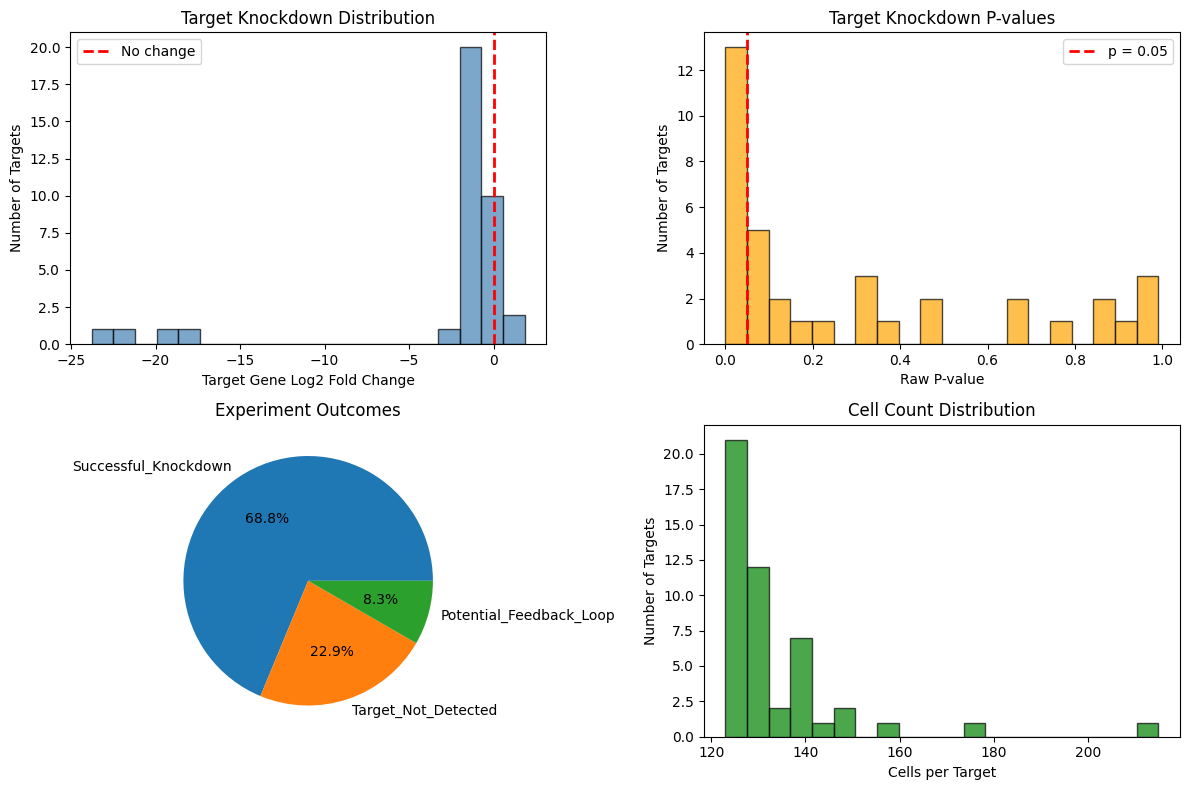


 Validation analysis saved to: target_validation.csv

  SUMMARY:
Most experiments worked well
Feedback loops are rare
Focus on 33 straightforward knockdowns for pathway analysis


In [71]:
# Comprehensive target knockdown analysis 
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def target_validation_analysis():
    """
    1. Check if experiments actually worked (targets knocked down)
    2. Flag feedback loops (targets that increased instead of decreased)  
    3. Use raw p-values for intuition building (no FDR correction)
    4. Focus on straightforward cases first
    """
    
    print("TARGET KNOCKDOWN VALIDATION ANALYSIS")
    print("Goal: Understand if experiments worked & flag feedback loops")
    print("=" * 70)
    
    # Get all 48 perturbations for comprehensive validation
    all_target_results = []
    
    for gene in perturbation_genes:
        try:
            result = sc.get.rank_genes_groups_df(adata_de, group=gene)
            target_row = result[result['names'] == gene]
            
            if len(target_row) > 0:
                target_logfc = target_row.iloc[0]['logfoldchanges']
                target_pval_raw = target_row.iloc[0]['pvals']
                target_pval_adj = target_row.iloc[0]['pvals_adj']
                
                # classification logic
                if target_logfc < 0:
                    experiment_result = "Successful_Knockdown"
                    analysis_flag = "Use_for_analysis"
                elif target_logfc > 0:
                    experiment_result = "Potential_Feedback_Loop"
                    analysis_flag = "Flag_and_set_aside"
                else:
                    experiment_result = "No_Change"
                    analysis_flag = "Unclear"
                
                # Statistical significance (raw p-values )
                significant_raw = target_pval_raw < 0.05
                
                all_target_results.append({
                    'Gene': gene,
                    'Target_LogFC': target_logfc,
                    'Raw_Pvalue': target_pval_raw,
                    'FDR_Pvalue': target_pval_adj,
                    'Significant_Raw': significant_raw,
                    'Experiment_Result': experiment_result,
                    'analysis_flag': analysis_flag,
                    'Cell_Count': (adata_de.obs['Gene'] == gene).sum()
                })
            else:
                # Target not detected
                all_target_results.append({
                    'Gene': gene,
                    'Target_LogFC': None,
                    'Raw_Pvalue': None,
                    'FDR_Pvalue': None,
                    'Significant_Raw': False,
                    'Experiment_Result': "Target_Not_Detected",
                    'analysis_flag': "Experiment_failed",
                    'Cell_Count': (adata_de.obs['Gene'] == gene).sum()
                })
                
        except Exception as e:
            print(f"Error processing {gene}: {e}")
            continue
    
    # Convert to DataFrame
    validation_df = pd.DataFrame(all_target_results)
    
    return validation_df

# Runvalidation analysis
target_validation  = target_validation_analysis()

# Population Understanding (her key request)
print("\n POPULATION ANALYSIS ")
print("=" * 60)

# Overall experiment success rate
total_targets = len(target_validation )
successful_knockdowns = (target_validation ['Experiment_Result'] == 'Successful_Knockdown').sum()
feedback_loops = (target_validation ['Experiment_Result'] == 'Potential_Feedback_Loop').sum()
not_detected = (target_validation ['Experiment_Result'] == 'Target_Not_Detected').sum()

print(f"Total targets analyzed: {total_targets}")
print(f"Successful knockdowns: {successful_knockdowns} ({successful_knockdowns/total_targets*100:.1f}%)")
print(f"Potential feedback loops: {feedback_loops} ({feedback_loops/total_targets*100:.1f}%)")
print(f"Target not detected: {not_detected} ({not_detected/total_targets*100:.1f}%)")

# feedback loops to flag and set aside
feedback_targets = target_validation [target_validation ['analysis_flag'] == 'Flag_and_set_aside']
straightforward_targets = target_validation [target_validation ['analysis_flag'] == 'Use_for_analysis']

print(f"\n FEEDBACK LOOPS TO FLAG):")
if len(feedback_targets) > 0:
    print("Targets that INCREASED after knockdown (potential feedback):")
    for _, row in feedback_targets.iterrows():
        print(f"  {row['Gene']}: +{row['Target_LogFC']:.2f} log2FC, p = {row['Raw_Pvalue']:.2e}")
else:
    print("No clear feedback loops detected")

print(f"\n STRAIGHTFORWARD CASES FOR ANALYSIS:")
print(f"Targets with successful knockdown: {len(straightforward_targets)}")
for _, row in straightforward_targets.head(10).iterrows():
    significance = "significant" if row['Significant_Raw'] else "not significant"
    print(f"  {row['Gene']}: {row['Target_LogFC']:.2f} log2FC, p = {row['Raw_Pvalue']:.2e} ({significance})")

# histogram for population understanding
plt.figure(figsize=(12, 8))

# Subplot 1: Target knockdown fold changes
plt.subplot(2, 2, 1)
detected_targets = target_validation [target_validation ['Target_LogFC'].notna()]
plt.hist(detected_targets['Target_LogFC'], bins=20, alpha=0.7, color='steelblue', edgecolor='black')
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='No change')
plt.xlabel('Target Gene Log2 Fold Change')
plt.ylabel('Number of Targets')
plt.title('Target Knockdown Distribution')
plt.legend()

# Subplot 2: Raw p-values distribution  
plt.subplot(2, 2, 2)
pvals = detected_targets['Raw_Pvalue'].dropna()
plt.hist(pvals, bins=20, alpha=0.7, color='orange', edgecolor='black')
plt.axvline(x=0.05, color='red', linestyle='--', linewidth=2, label='p = 0.05')
plt.xlabel('Raw P-value')
plt.ylabel('Number of Targets')
plt.title('Target Knockdown P-values')
plt.legend()

# Subplot 3: Experiment outcome pie chart
plt.subplot(2, 2, 3)
outcome_counts = target_validation ['Experiment_Result'].value_counts()
plt.pie(outcome_counts.values, labels=outcome_counts.index, autopct='%1.1f%%')
plt.title('Experiment Outcomes')

# Subplot 4: Cell count distribution
plt.subplot(2, 2, 4)
plt.hist(target_validation ['Cell_Count'], bins=20, alpha=0.7, color='green', edgecolor='black')
plt.xlabel('Cells per Target')
plt.ylabel('Number of Targets')
plt.title('Cell Count Distribution')

plt.tight_layout()
plt.show()

# Save validation results
target_validation .to_csv("/Users/prashammarfatia/Downloads/target_validation.csv", index=False)

print(f"\n Validation analysis saved to: target_validation.csv")
print(f"\n  SUMMARY:")
print(f"Most experiments {'worked well' if successful_knockdowns > total_targets*0.5 else 'had issues'}")
print(f"Feedback loops are {'common' if feedback_loops > total_targets*0.1 else 'rare'}")
print(f"Focus on {len(straightforward_targets)} straightforward knockdowns for pathway analysis")

In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from typing import Dict, List, Tuple, Optional
import warnings
warnings.filterwarnings('ignore')

def validate_gene_nomenclature(gene_list: List[str]) -> Dict[str, List[str]]:
    """
    Validate gene nomenclature according to HUGO standards.
    
    Args:
        gene_list: List of gene symbols to validate
        
    Returns:
        Dictionary containing categorized gene name issues
    """
    validation_results = {
        'lowercase_genes': [],
        'tss2_variants': [],
        'enhancer_elements': [],
        'chromosomal_coordinates': [],
        'valid_genes': []
    }
    
    for gene in gene_list:
        if pd.isna(gene):
            continue
            
        gene_str = str(gene)
        
        # Check for lowercase characters (non-standard for human genes)
        if gene_str != gene_str.upper():
            validation_results['lowercase_genes'].append(gene_str)
        # Check for TSS2 variants (transcription start site variants)
        elif '-TSS2' in gene_str:
            validation_results['tss2_variants'].append(gene_str)
        # Check for enhancer elements
        elif gene_str.startswith('Enhancer-') or '-etc-' in gene_str:
            validation_results['enhancer_elements'].append(gene_str)
        # Check for chromosomal coordinate notation
        elif gene_str.startswith('chr') or any(char.isdigit() for char in gene_str.split('-')):
            validation_results['chromosomal_coordinates'].append(gene_str)
        else:
            validation_results['valid_genes'].append(gene_str)
    
    return validation_results

In [73]:
def analyze_gene_nomenclature_issues(adata_object, perturbation_targets: List[str]) -> Tuple[List[str], Dict]:
    """
    Comprehensive analysis of gene nomenclature issues in the dataset.
    
    Args:
        adata_object: AnnData object containing expression data
        perturbation_targets: List of perturbation target genes
        
    Returns:
        Tuple of (clean_targets, validation_results)
    """
    print("GENE NOMENCLATURE VALIDATION ANALYSIS")
    print("=" * 60)
    
    # Collect all unique gene symbols
    all_genes = set()
    all_genes.update(adata_object.var_names.tolist())
    all_genes.update(adata_object.obs['Gene'].unique().tolist())
    all_genes = [g for g in all_genes if pd.notna(g)]
    
    # Validate nomenclature
    validation_results = validate_gene_nomenclature(all_genes)
    
    # Report findings
    print(f"Total unique genes analyzed: {len(all_genes)}")
    print(f"Valid gene names: {len(validation_results['valid_genes'])}")
    print(f"Genes with lowercase letters: {len(validation_results['lowercase_genes'])}")
    print(f"TSS2 variant genes: {len(validation_results['tss2_variants'])}")
    print(f"Enhancer elements: {len(validation_results['enhancer_elements'])}")
    print(f"Chromosomal coordinate genes: {len(validation_results['chromosomal_coordinates'])}")
    
    # Examine perturbation targets specifically
    print("\nPERTURBATION TARGET VALIDATION:")
    target_validation = validate_gene_nomenclature(perturbation_targets)
    
    problematic_targets = []
    for category, genes in target_validation.items():
        if category != 'valid_genes' and genes:
            problematic_targets.extend(genes)
            print(f"{category}: {genes}")
    
    clean_targets = [gene for gene in perturbation_targets if gene not in problematic_targets]
    print(f"\nClean perturbation targets: {len(clean_targets)}/{len(perturbation_targets)}")
    
    return clean_targets, validation_results

In [74]:
def progressive_pathway_analysis(target_gene: str, adata_object, max_path_length: int = 3) -> pd.DataFrame:
    """
    Progressive hop-by-hop pathway analysis from target to downstream genes.
    
    Args:
        target_gene: Starting gene for pathway analysis
        adata_object: AnnData object containing differential expression results
        max_path_length: Maximum number of hops to analyze
        
    Returns:
        DataFrame containing identified pathways with metadata
    """
    # Retrieve differential expression results for target gene
    try:
        de_results = sc.get.rank_genes_groups_df(adata_object, group=target_gene)
    except Exception as e:
        print(f"Error retrieving DE results for {target_gene}: {e}")
        return pd.DataFrame()
    
    # Validate target gene knockdown
    target_row = de_results[de_results['names'] == target_gene]
    if len(target_row) == 0:
        print(f"Target gene {target_gene} not found in DE results")
        return pd.DataFrame()
    
    target_logfc = target_row.iloc[0]['logfoldchanges']
    target_pvalue = target_row.iloc[0]['pvals_adj']
    
    # Only proceed with statistically significant knockdowns
    if target_pvalue >= 0.05:
        print(f"Target gene {target_gene} knockdown not statistically significant")
        return pd.DataFrame()
    
    # Only proceed with successful knockdowns (negative fold change)
    if target_logfc >= 0:
        print(f"Target gene {target_gene} shows feedback loop behavior, skipping")
        return pd.DataFrame()
    
    print(f"Analyzing {target_gene}: {target_logfc:.2f} log2FC, p-adj = {target_pvalue:.2e}")
    
    # Identify significant downstream targets
    downstream_genes = de_results[de_results['names'] != target_gene]
    significant_downstream = downstream_genes[downstream_genes['pvals_adj'] < 0.05]
    
    pathway_results = []
    
    # Hop 1: Direct target-to-downstream relationships
    for _, row in significant_downstream.iterrows():
        downstream_gene = row['names']
        downstream_logfc = row['logfoldchanges']
        downstream_pvalue = row['pvals_adj']
        
        # Determine regulatory relationship direction
        if downstream_logfc > 0:
            regulatory_relationship = "inhibitory"
            edge_notation = "decreases_amount"
        else:
            regulatory_relationship = "activating"
            edge_notation = "increases_amount"
        
        pathway_results.append({
            'source_gene': target_gene,
            'target_gene': downstream_gene,
            'path_length': 1,
            'pathway_string': f"{target_gene} -> {downstream_gene}",
            'regulatory_relationship': regulatory_relationship,
            'final_edge_type': edge_notation,
            'downstream_logfc': downstream_logfc,
            'downstream_pvalue': downstream_pvalue,
            'pathway_confidence': 'direct_evidence'
        })
    
    print(f"Identified {len(pathway_results)} direct pathways")
    
    # Hop 2: Search for indirect pathways through intermediates
    if max_path_length >= 2:
        two_hop_count = 0
        perturbation_gene_set = set(adata_object.obs['Gene'].unique())
        
        for _, intermediate_row in significant_downstream.head(20).iterrows():
            intermediate_gene = intermediate_row['names']
            
            # Check if intermediate gene is also a perturbation target
            if intermediate_gene in perturbation_gene_set:
                try:
                    intermediate_de_results = sc.get.rank_genes_groups_df(adata_object, group=intermediate_gene)
                    intermediate_downstream = intermediate_de_results[
                        intermediate_de_results['pvals_adj'] < 0.1
                    ]
                    
                    for _, final_row in intermediate_downstream.iterrows():
                        final_gene = final_row['names']
                        
                        # Check if this creates a valid 2-hop path to an original downstream target
                        original_targets = significant_downstream['names'].tolist()
                        if final_gene in original_targets:
                            final_logfc = final_row['logfoldchanges']
                            
                            # Determine final edge type (must be expression-based)
                            final_edge_type = "increases_amount" if final_logfc > 0 else "decreases_amount"
                            
                            pathway_string = f"{target_gene} -> {intermediate_gene} -> {final_gene}"
                            
                            pathway_results.append({
                                'source_gene': target_gene,
                                'target_gene': final_gene,
                                'path_length': 2,
                                'pathway_string': pathway_string,
                                'regulatory_relationship': 'indirect',
                                'final_edge_type': final_edge_type,
                                'downstream_logfc': final_logfc,
                                'downstream_pvalue': final_row['pvals_adj'],
                                'pathway_confidence': 'indirect_evidence',
                                'intermediate_gene': intermediate_gene
                            })
                            two_hop_count += 1
                            
                except Exception as e:
                    continue
        
        print(f"Identified {two_hop_count} two-hop pathways")
    
    return pd.DataFrame(pathway_results)

In [75]:
# Step 1: Validate gene nomenclature
clean_targets, nomenclature_validation = analyze_gene_nomenclature_issues(
    adata_de, 
    perturbation_genes
)

# Display results
print("\nNomenclature validation complete")
print(f"Clean targets available: {len(clean_targets)}")

GENE NOMENCLATURE VALIDATION ANALYSIS
Total unique genes analyzed: 873
Valid gene names: 858
Genes with lowercase letters: 10
TSS2 variant genes: 5
Enhancer elements: 0
Chromosomal coordinate genes: 0

PERTURBATION TARGET VALIDATION:
lowercase_genes: ['Tm4sf1', 'Cytl1', 'Enhancer-BP-etc-chr2-43395808-43396308', 'C18orf32', 'Palmd']
tss2_variants: ['MVB12A-TSS2', 'TRIB1-TSS2', 'RNPEP-TSS2', 'CBX5-TSS2', 'ACVR2A-TSS2']

Clean perturbation targets: 38/48

Nomenclature validation complete
Clean targets available: 38


In [76]:
import pandas as pd
# Step 2: Filter to experimentally validated successful knockdowns
target_validation_df = pd.read_csv("/Users/prashammarfatia/Downloads/target_validation.csv")
successful_knockdown_targets = target_validation_df[
    target_validation_df['analysis_flag'] == 'Use_for_analysis'
]['Gene'].tolist()

# Step 3: Combine clean nomenclature with successful knockdowns
analysis_ready_targets = [
    gene for gene in successful_knockdown_targets 
    if gene in clean_targets
]

print(f"Successful knockdown targets: {len(successful_knockdown_targets)}")
print(f"Targets ready for pathway analysis: {len(analysis_ready_targets)}")
print(f"Analysis-ready targets: {analysis_ready_targets[:10]}...")

Successful knockdown targets: 33
Targets ready for pathway analysis: 32
Analysis-ready targets: ['CALCOCO1', 'PVT1', 'SMAD3', 'PCMTD2', 'BABAM1', 'PRPH2', 'LPIN3', 'PROX1', 'ATP6V0E2', 'GSTO2']...


In [77]:
# Step 4: Execute progressive pathway analysis
print("PROGRESSIVE PATHWAY ANALYSIS")
print("Requirements: 1-hop -> 2-hop -> 3-hop progression")
print("Final edges must represent mRNA abundance changes")
print("=" * 70)

all_pathway_results = []

for target_gene in analysis_ready_targets:
    print(f"\nAnalyzing target: {target_gene}")
    target_pathways = progressive_pathway_analysis(target_gene, adata_de, max_path_length=3)
    
    if not target_pathways.empty:
        all_pathway_results.append(target_pathways)

PROGRESSIVE PATHWAY ANALYSIS
Requirements: 1-hop -> 2-hop -> 3-hop progression
Final edges must represent mRNA abundance changes

Analyzing target: CALCOCO1
Target gene CALCOCO1 knockdown not statistically significant

Analyzing target: PVT1
Analyzing PVT1: -0.74 log2FC, p-adj = 1.83e-02
Identified 38 direct pathways
Identified 0 two-hop pathways

Analyzing target: SMAD3
Target gene SMAD3 knockdown not statistically significant

Analyzing target: PCMTD2
Target gene PCMTD2 knockdown not statistically significant

Analyzing target: BABAM1
Target gene BABAM1 knockdown not statistically significant

Analyzing target: PRPH2
Target gene PRPH2 knockdown not statistically significant

Analyzing target: LPIN3
Target gene LPIN3 knockdown not statistically significant

Analyzing target: PROX1
Target gene PROX1 knockdown not statistically significant

Analyzing target: ATP6V0E2
Target gene ATP6V0E2 knockdown not statistically significant

Analyzing target: GSTO2
Target gene GSTO2 knockdown not sta

In [78]:
# Combine all pathway results
if not all_pathway_results:
    print("No valid pathways identified")
else:
    complete_pathway_analysis = pd.concat(all_pathway_results, ignore_index=True)
    
    # Generate summary statistics
    total_pathways = len(complete_pathway_analysis)
    direct_pathways = len(complete_pathway_analysis[complete_pathway_analysis['path_length'] == 1])
    indirect_pathways = len(complete_pathway_analysis[complete_pathway_analysis['path_length'] > 1])
    
    print(f"\nPATHWAY ANALYSIS SUMMARY:")
    print(f"Total pathways identified: {total_pathways}")
    print(f"Direct pathways (1-hop): {direct_pathways}")
    print(f"Indirect pathways (2+ hops): {indirect_pathways}")
    
    # Analyze edge types
    edge_type_distribution = complete_pathway_analysis['final_edge_type'].value_counts()
    print(f"\nFinal edge type distribution:")
    for edge_type, count in edge_type_distribution.items():
        print(f"  {edge_type}: {count}")
    
    # Save results
    output_filepath = "/Users/prashammarfatia/Downloads/progressive_pathway_analysis.csv"
    complete_pathway_analysis.to_csv(output_filepath, index=False)
    print(f"\nPathway analysis results saved to: {output_filepath}")


PATHWAY ANALYSIS SUMMARY:
Total pathways identified: 496
Direct pathways (1-hop): 496
Indirect pathways (2+ hops): 0

Final edge type distribution:
  decreases_amount: 313
  increases_amount: 183

Pathway analysis results saved to: /Users/prashammarfatia/Downloads/progressive_pathway_analysis.csv
